In [1]:
import pickle

with open("/kaggle/input/datasets/tsyaidfarhan/cq500-preprocessed-cache/cq500_splits.pkl", "rb") as f:
    splits = pickle.load(f)

print("Splits loaded successfully.")


Splits loaded successfully.


In [2]:
import os
import pickle
import math
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
import timm
import matplotlib.pyplot as plt

In [3]:
# =====================
# Reproducibility
# =====================
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# =====================
# Paths & Config
# =====================
DATA_ROOT = "/kaggle/input/datasets/tsyaidfarhan/cq500-preprocessed-cache"
CACHE_ROOT = DATA_ROOT + "/cache/cache"
SPLITS_PATH = DATA_ROOT + "/cq500_splits.pkl"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================
# EXPERIMENT — Change this manually to the subtype you want
# =====================
EXPERIMENT_NAME = "any_ich"   # <-- CHANGE THIS to: "any_ich", "iph", "sdh", "sah", "edh", "ivh"

# =====================
# BACKBONE — ConvNeXt-Tiny (Deep Learning) vs LightGBM (Machine Learning)
# =====================
BACKBONE_NAMES = ["convnext_tiny"]

# Hyperparameters
EPOCHS = 30                   # reduced from 40 (early stopping will cut further)
BATCH_SIZE = 32
LEARNING_RATE = 3e-5          # lower LR for pretrained backbone
WEIGHT_DECAY = 5e-2           # stronger regularization
GRAD_ACCUM_STEPS = 2          # effective batch size = 32 * 2 = 64
PATIENCE = 7                  # reduced from 10 — stop earlier to save time

# =====================
# SLICE CAP — limits total slices in the DL dataset to speed up training
# Set to None to use all slices (original behaviour)
# =====================
MAX_SLICES_TOTAL = 15000      # cap total train slices; ~15 k is enough for good AUC

print("Using device:", DEVICE)
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"DL Backbone: {BACKBONE_NAMES[0]}")
print(f"ML Baseline: LightGBM + Radiomics")
print(f"Max slices cap: {MAX_SLICES_TOTAL}")


Using device: cuda
Experiment: any_ich
DL Backbone: convnext_tiny
ML Baseline: LightGBM + Radiomics
Max slices cap: 15000


In [4]:
import os

print("Example folder:", os.listdir(CACHE_ROOT)[:5])


Example folder: ['CQ500CT102', 'CQ500CT136', 'CQ500CT204', 'CQ500CT245', 'CQ500CT338']


In [5]:
print("CACHE_ROOT:", CACHE_ROOT)
print("Example study:", splits["any_ich"]["train"].iloc[0]["study_id"])

import os

test_study = splits["any_ich"]["train"].iloc[0]["study_id"]
test_path = os.path.join(CACHE_ROOT, test_study)

print("Study exists?", os.path.exists(test_path))
print("Files inside:", os.listdir(test_path)[:5] if os.path.exists(test_path) else "Not found")


CACHE_ROOT: /kaggle/input/datasets/tsyaidfarhan/cq500-preprocessed-cache/cache/cache
Example study: CQ500CT201
Study exists? True
Files inside: ['422.npy', '331.npy', '280.npy', '100.npy', '193.npy']


In [6]:
for exp_name, split_data in splits.items():
    
    print("\n", exp_name.upper())
    
    for subset in ["train","val","test"]:
        df_subset = split_data[subset]
        pos = df_subset["label"].sum()
        total = len(df_subset)
        print(f"{subset}: Positif {pos}/{total}")



 ANY_ICH
train: Positif 134/331
val: Positif 29/71
test: Positif 28/71

 IPH
train: Positif 90/287
val: Positif 20/62
test: Positif 19/62

 SDH
train: Positif 34/231
val: Positif 8/50
test: Positif 7/50

 SAH
train: Positif 40/237
val: Positif 9/51
test: Positif 8/51


In [7]:
from scipy.ndimage import rotate, affine_transform, gaussian_filter, map_coordinates

class AugmentationPipeline:
    """Enhanced augmentation pipeline for medical imaging."""
    
    def __init__(self, mode="train"):
        self.mode = mode
        
        # Probability control — slightly more aggressive for medical images
        self.p_flip = 0.5
        self.p_rotation = 0.7
        self.p_shift = 0.4
        self.p_noise = 0.3
        self.p_brightness = 0.3
        self.p_intensity = 0.4
        self.p_contrast = 0.4
        self.p_elastic = 0.2       # NEW: elastic deformation
        self.p_cutout = 0.3        # NEW: random erasing / cutout
    
    # -------------------------
    # Geometric Transformations
    # -------------------------
    
    def horizontal_flip(self, image):
        return np.flip(image, axis=1).copy()
    
    def random_rotation(self, image):
        angle = random.uniform(-20, 20)
        return rotate(image, angle, reshape=False, order=1, mode="nearest")
    
    def random_shift(self, image, max_shift_ratio=0.08):
        shift_x = image.shape[0] * max_shift_ratio * random.uniform(-1, 1)
        shift_y = image.shape[1] * max_shift_ratio * random.uniform(-1, 1)
        matrix = np.array([[1, 0], [0, 1]])
        offset = [-shift_x, -shift_y]
        return affine_transform(image, matrix, offset=offset, order=1, mode="nearest")
    
    def elastic_deformation(self, image, alpha=15, sigma=3):
        """Elastic deformation — effective for CT scans to simulate tissue variation."""
        shape = image.shape
        dx = gaussian_filter(np.random.randn(*shape) * alpha, sigma)
        dy = gaussian_filter(np.random.randn(*shape) * alpha, sigma)
        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = [np.clip(y + dy, 0, shape[0] - 1), np.clip(x + dx, 0, shape[1] - 1)]
        return map_coordinates(image, indices, order=1, mode="nearest").reshape(shape)
    
    # -------------------------
    # Intensity Transformations
    # -------------------------
    
    def gaussian_noise(self, image):
        std = random.uniform(0.005, 0.02)
        noise = np.random.normal(0, std, image.shape)
        return np.clip(image + noise, 0, 1)
    
    def brightness(self, image):
        factor = random.uniform(0.85, 1.15)
        return np.clip(image * factor, 0, 1)
    
    def random_intensity(self, image):
        scale = random.uniform(0.85, 1.15)
        shift = random.uniform(-0.05, 0.05)
        return np.clip(image * scale + shift, 0, 1)
    
    def contrast(self, image):
        mean = np.mean(image)
        factor = random.uniform(0.75, 1.25)
        return np.clip((image - mean) * factor + mean, 0, 1)
    
    def cutout(self, image, max_holes=2, max_size=0.15):
        """Random rectangular cutout — forces model to use global context."""
        h, w = image.shape
        img = image.copy()
        n_holes = random.randint(1, max_holes)
        for _ in range(n_holes):
            sz_h = int(h * random.uniform(0.05, max_size))
            sz_w = int(w * random.uniform(0.05, max_size))
            y = random.randint(0, h - sz_h)
            x = random.randint(0, w - sz_w)
            img[y:y+sz_h, x:x+sz_w] = 0.0
        return img
    
    # -------------------------
    # Main Pipeline
    # -------------------------
    
    def apply(self, image):
        if self.mode != "train":
            return image.astype(np.float32)
        
        # GEOMETRIC
        if random.random() < self.p_flip:
            image = self.horizontal_flip(image)
        if random.random() < self.p_rotation:
            image = self.random_rotation(image)
        if random.random() < self.p_shift:
            image = self.random_shift(image)
        if random.random() < self.p_elastic:
            image = self.elastic_deformation(image)
        
        # INTENSITY
        if random.random() < self.p_contrast:
            image = self.contrast(image)
        if random.random() < self.p_intensity:
            image = self.random_intensity(image)
        if random.random() < self.p_brightness:
            image = self.brightness(image)
        
        # NOISE + CUTOUT last
        if random.random() < self.p_noise:
            image = self.gaussian_noise(image)
        if random.random() < self.p_cutout:
            image = self.cutout(image)
        
        return image.astype(np.float32)

In [8]:
def visualize_augmentation_safe(dataset_df, processor, preprocess,
                                study_idx=0, slice_idx=0, n_aug=6):
    
    import matplotlib.pyplot as plt
    
    row = dataset_df.iloc[study_idx]
    slice_idx = min(slice_idx, len(row["dicom_files"]) - 1)
    dicom_path = row["dicom_files"][slice_idx]
    
    raw = processor.read_hu(dicom_path)
    windowed = processor.brain_window(raw)
    resized = preprocess.resize(windowed)
    
    augmenter = AugmentationPipeline()
    
    total_images = n_aug + 1  # +1 untuk original
    
    cols = 4
    rows = int(np.ceil(total_images / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten()
    
    # Original
    axes[0].imshow(resized, cmap="gray")
    axes[0].set_title("Preprocessed")
    axes[0].axis("off")
    
    # Augmented
    for i in range(n_aug):
        aug_img = augmenter.apply(resized.copy())
        
        axes[i+1].imshow(aug_img, cmap="gray")
        axes[i+1].set_title(f"Aug {i+1}")
        axes[i+1].axis("off")
    
    # Hide empty plots
    for j in range(total_images, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()


In [9]:
# ImageNet normalization stats (critical for pretrained backbones)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class CachedSliceDataset(Dataset):

    def __init__(self, df, cache_root, augment=False, normalize=True, max_slices=None):
        """
        max_slices: if set, randomly subsample the slice list to this total
                    (preserves class ratio across studies).
        """
        self.samples = []
        self.cache_root = cache_root
        self.augment = augment
        self.normalize = normalize
        self.augmenter = AugmentationPipeline(mode="train" if augment else "val")

        for _, row in df.iterrows():
            study_id = row["study_id"]
            label = row["label"]

            study_dir = os.path.join(cache_root, study_id)
            if not os.path.exists(study_dir):
                continue

            for f in sorted(os.listdir(study_dir)):
                if f.endswith(".npy"):
                    self.samples.append(
                        (os.path.join(study_dir, f), label, study_id)
                    )

        # Optional: cap total slices to speed up training
        if max_slices is not None and len(self.samples) > max_slices:
            random.seed(SEED)
            self.samples = random.sample(self.samples, max_slices)
            print(f"    [CachedSliceDataset] Capped to {max_slices} slices "
                  f"(from {len(self.samples) + (len(self.samples) - max_slices)} total)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, study_id = self.samples[idx]

        img = np.load(path).astype(np.float32)

        if self.augment:
            img = self.augmenter.apply(img)

        # Stack to 3-channel
        img = torch.tensor(img, dtype=torch.float32)
        img = torch.stack([img, img, img])  # (3, H, W)

        # ImageNet normalization for pretrained weights
        if self.normalize:
            img = (img - IMAGENET_MEAN) / IMAGENET_STD

        label = torch.tensor(label, dtype=torch.float32)

        return img, label, study_id


In [10]:
import torchvision.models as models

class GeM(nn.Module):
    """Generalized Mean Pooling — better than AvgPool for classification."""
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p), 1
        ).pow(1.0 / self.p)


class ICHModel(nn.Module):
    
    def __init__(self, backbone_name="convnext_tiny", dropout=0.4):
        super().__init__()
        self.backbone_name = backbone_name
        
        backbone = models.convnext_tiny(weights="IMAGENET1K_V1")
        in_features = backbone.classifier[2].in_features
        backbone.classifier = nn.Identity()
        
        self.backbone = backbone
        
        # Classification head with GeM pooling
        self.pool = GeM(p=3.0)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        if features.dim() == 4:
            features = self.pool(features)
        elif features.dim() == 2:
            features = features.unsqueeze(-1).unsqueeze(-1)
            features = self.pool(features)
        return self.head(features)
    
    def get_optimizer_groups(self, lr=3e-5, wd=5e-2, lr_decay=0.8):
        """Layer-wise LR decay — lower LR for early layers, higher for head."""
        backbone_params = list(self.backbone.parameters())
        head_params = list(self.pool.parameters()) + list(self.head.parameters())
        
        n_layers = len(backbone_params)
        groups = []
        for i, p in enumerate(backbone_params):
            layer_lr = lr * (lr_decay ** (n_layers - i - 1))
            groups.append({"params": [p], "lr": layer_lr, "weight_decay": wd})
        
        groups.append({"params": head_params, "lr": lr * 5, "weight_decay": wd})
        return groups

print("ICHModel defined (ConvNeXt-Tiny + GeM pooling).")


ICHModel defined (ConvNeXt-Tiny + GeM pooling).


In [11]:
# =====================
# Helper: Build DataLoaders for the chosen experiment
# =====================
def build_loaders(experiment_name, splits, cache_root, batch_size=32,
                  max_train_slices=None):
    """Create train/val/test loaders with weighted sampling for a given experiment.
    
    max_train_slices: cap total training slices (None = use all).
    """
    
    train_dataset = CachedSliceDataset(
        splits[experiment_name]["train"], cache_root,
        augment=True, normalize=True, max_slices=max_train_slices
    )
    val_dataset = CachedSliceDataset(
        splits[experiment_name]["val"], cache_root, augment=False, normalize=True
    )
    test_dataset = CachedSliceDataset(
        splits[experiment_name]["test"], cache_root, augment=False, normalize=True
    )
    
    # Weighted sampling for class imbalance
    labels_list = [s[1] for s in train_dataset.samples]
    n_pos = sum(labels_list)
    n_neg = len(labels_list) - n_pos
    weight_pos = len(labels_list) / (2.0 * max(n_pos, 1))
    weight_neg = len(labels_list) / (2.0 * max(n_neg, 1))
    sample_weights = [weight_pos if l == 1 else weight_neg for l in labels_list]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, sampler=sampler,
        num_workers=4, pin_memory=True, persistent_workers=True, drop_last=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
    )
    
    print(f"  [{experiment_name}] Train: {len(train_dataset)} slices "
          f"({int(n_pos)} pos, {int(n_neg)} neg) | "
          f"Val: {len(val_dataset)} | Test: {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader

# Build loaders once for the chosen experiment
print(f"\nExperiment: {EXPERIMENT_NAME}")
print(f"Backbones to compare: {BACKBONE_NAMES}")



Experiment: any_ich
Backbones to compare: ['convnext_tiny']


In [12]:
class FocalLoss(nn.Module):
    """Focal Loss with label smoothing for better calibration."""
    
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # Apply label smoothing
        targets_smooth = targets.float() * (1 - self.label_smoothing) + self.label_smoothing * 0.5
        
        bce = F.binary_cross_entropy_with_logits(
            logits, targets_smooth, reduction="none"
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets >= 0.5, probs, 1 - probs)
        
        alpha_t = torch.where(targets >= 0.5, self.alpha, 1 - self.alpha)
        loss = alpha_t * (1 - pt) ** self.gamma * bce
        return loss.mean()

print("FocalLoss defined (alpha=0.75, gamma=2.0, label_smoothing=0.05)")

FocalLoss defined (alpha=0.75, gamma=2.0, label_smoothing=0.05)


In [13]:
def validate_patient_level_test(model, val_loader, device):
    """Original Code 14 - Just works, no errors"""
    
    model.eval()
    slice_dict = defaultdict(list)
    labels = {}
    
    with torch.no_grad():
        for images, batch_labels, study_ids in val_loader:
            images = images.to(device)
            probs = torch.sigmoid(model(images)).cpu().numpy().flatten()
            
            for i in range(len(probs)):
                sid = study_ids[i]
                slice_dict[sid].append(probs[i])
                labels[sid] = batch_labels[i].item()
    
    y_true, y_pred = [], []
    
    for sid in slice_dict:
        preds = np.array(slice_dict[sid])
        k = max(1, int(len(preds) * 0.10))
        top_k_mean = np.mean(np.sort(preds)[-k:])
        
        sorted_preds = np.sort(preds)
        weights = np.exp(np.linspace(0, 2, len(sorted_preds)))
        exp_weighted_mean = np.average(sorted_preds, weights=weights)
        
        combined = 0.6 * top_k_mean + 0.4 * exp_weighted_mean
        
        y_pred.append(combined)
        y_true.append(labels[sid])
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    if len(np.unique(y_true)) < 2:
        return {
            'auc': 0.5, 'sensitivity': 0, 'specificity': 0,
            'ppv': 0, 'npv': 0, 'accuracy': 0, 'threshold': 0.5,
            'y_true': y_true, 'y_pred': y_pred
        }
    
    auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    youden_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[youden_idx]
    
    y_pred_binary = (y_pred >= optimal_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred_binary)
    
    return {
        'auc': auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'accuracy': accuracy,
        'threshold': optimal_threshold,
        'y_true': y_true,
        'y_pred': y_pred
    }

In [14]:
def validate_patient_level(model, val_loader, device, criterion):
    """
    Compute validation loss + patient-level metrics in a SINGLE pass.
    
    This is much faster than computing them separately.
    """
    model.eval()
    val_loss = 0.0
    slice_dict = defaultdict(list)
    labels = {}
    val_steps = 0
    
    with torch.no_grad():
        for images, batch_labels, study_ids in val_loader:
            images = images.to(device)
            batch_labels_device = batch_labels.unsqueeze(1).to(device)
            
            # Single forward pass
            logits = model(images)
            
            # Compute loss
            loss = criterion(logits, batch_labels_device)
            val_loss += loss.item()
            val_steps += 1
            
            # Compute probabilities
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            
            # Aggregate for patient-level
            for i in range(len(probs)):
                sid = study_ids[i]
                slice_dict[sid].append(probs[i])
                labels[sid] = batch_labels[i].item()
    
    # Average loss
    val_loss = val_loss / max(val_steps, 1)
    
    # Compute metrics (same as before)
    y_true, y_pred = [], []
    for sid in slice_dict:
        preds = np.array(slice_dict[sid])
        k = max(1, int(len(preds) * 0.10))
        top_k_mean = np.mean(np.sort(preds)[-k:])
        
        sorted_preds = np.sort(preds)
        weights = np.exp(np.linspace(0, 2, len(sorted_preds)))
        exp_weighted_mean = np.average(sorted_preds, weights=weights)
        
        combined = 0.6 * top_k_mean + 0.4 * exp_weighted_mean
        
        y_pred.append(combined)
        y_true.append(labels[sid])
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Handle single-class case
    if len(np.unique(y_true)) < 2:
        return {
            'auc': 0.5, 'sensitivity': 0, 'specificity': 0,
            'ppv': 0, 'npv': 0, 'accuracy': 0, 'threshold': 0.5,
            'y_true': y_true, 'y_pred': y_pred, 'val_loss': val_loss
        }
    
    auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    youden_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[youden_idx]
    
    y_pred_binary = (y_pred >= optimal_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred_binary)
    
    return {
        'auc': auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'accuracy': accuracy,
        'threshold': optimal_threshold,
        'y_true': y_true,
        'y_pred': y_pred,
        'val_loss': val_loss  # ← Included!
    }



In [15]:
class EarlyStoppingAUC:
    def __init__(self, patience=15):
        self.best = 0
        self.counter = 0
        self.patience = patience

    def step(self, auc):
        if auc > self.best:
            self.best = auc
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

In [16]:
def train_experiment(train_loader,
                     val_loader,
                     experiment_name,
                     backbone_name,
                     device,
                     epochs=40,
                     patience=10,
                     lr=3e-5,
                     wd=5e-2,
                     grad_accum_steps=2):
    """
    Improved training pipeline with:
    - Layer-wise LR decay
    - Gradient accumulation (effective batch size = batch_size * accum_steps)
    - Cosine annealing with warm restarts
    - Gradient clipping
    - Best model saving by AUC
    - Validation loss tracking for overfitting analysis
    """
    
    model = ICHModel(backbone_name, dropout=0.4).to(device)
    criterion = FocalLoss(alpha=0.75, gamma=2.0, label_smoothing=0.05)
    
    # Layer-wise LR decay optimizer
    param_groups = model.get_optimizer_groups(lr=lr, wd=wd, lr_decay=0.85)
    optimizer = torch.optim.AdamW(param_groups)
    
    # Cosine Annealing with Warm Restarts
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-7
    )
    
    scaler = GradScaler()
    early_stopper = EarlyStoppingAUC(patience=patience)
    
    history = []
    best_auc = 0.0
    
    save_dir = f"/kaggle/working/checkpoints/{experiment_name}"
    os.makedirs(save_dir, exist_ok=True)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        train_preds = []
        train_labels = []
        
        optimizer.zero_grad()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for step, (images, labels, _) in enumerate(pbar):
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)
            
            with autocast():
                logits = model(images)
                loss = criterion(logits, labels) / grad_accum_steps
            
            scaler.scale(loss).backward()
            
            # Gradient accumulation
            if (step + 1) % grad_accum_steps == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            running_loss += loss.item() * grad_accum_steps
            
            # Track predictions
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).int()
                train_preds.extend(preds.cpu().numpy())
                train_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix(loss=f"{loss.item() * grad_accum_steps:.4f}")
        
        scheduler.step(epoch)
        
        epoch_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)
        # Patient-level validation
        metrics = validate_patient_level(model, val_loader, device, criterion)
        val_loss = metrics['val_loss']
        val_auc = metrics['auc']
        
        current_lr = optimizer.param_groups[-1]['lr']
        
        print(
            f"Epoch {epoch+1:02d} | "
            f"Loss {epoch_loss:.4f} | "
            f"ValLoss {val_loss:.4f} | "
            f"TrainAcc {train_acc:.4f} | "
            f"AUC {val_auc:.4f} | "
            f"Sens {metrics['sensitivity']:.4f} | "
            f"Spec {metrics['specificity']:.4f} | "
            f"LR {current_lr:.2e}"
        )
        
        history.append({
            "epoch": epoch + 1,
            "loss": epoch_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "lr": current_lr,
            **metrics
        })
        
        # Save best model
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(
                model.state_dict(),
                f"{save_dir}/{backbone_name}_best.pt"
            )
            print(f"  ✓ New best AUC: {best_auc:.4f} — model saved.")
        
        # Early stopping
        if early_stopper.step(val_auc):
            print(f"\n⏹ Early stopping at epoch {epoch+1} (best AUC: {best_auc:.4f})")
            break
    
    print(f"\n{'='*60}")
    print(f"Training complete. Best AUC: {best_auc:.4f}")
    print(f"{'='*60}")
    
    return model, history

In [17]:
# ============================================================
# Train ALL backbones on the chosen experiment
# ============================================================
all_histories = {}     # {backbone_name: [history_dicts]}
all_models = {}        # {backbone_name: model}

# Build loaders once (same data for all backbones)
# MAX_SLICES_TOTAL caps the training slices so each epoch is faster
train_loader, val_loader, _ = build_loaders(
    EXPERIMENT_NAME, splits, CACHE_ROOT,
    batch_size=BATCH_SIZE,
    max_train_slices=MAX_SLICES_TOTAL
)

for backbone_name in BACKBONE_NAMES:
    
    print(f"\n{'='*60}")
    print(f"  TRAINING: {backbone_name.upper()} on {EXPERIMENT_NAME.upper()}")
    print(f"{'='*60}")
    
    seed_everything(SEED)
    
    model, history = train_experiment(
        train_loader,
        val_loader,
        experiment_name=EXPERIMENT_NAME,
        backbone_name=backbone_name,
        device=DEVICE,
        epochs=EPOCHS,
        patience=PATIENCE,
        lr=LEARNING_RATE,
        wd=WEIGHT_DECAY,
        grad_accum_steps=GRAD_ACCUM_STEPS
    )
    
    all_histories[backbone_name] = history
    all_models[backbone_name] = model

print(f"\n{'='*60}")
print(f"All {len(BACKBONE_NAMES)} backbones trained on {EXPERIMENT_NAME.upper()}!")
print(f"{'='*60}")


    [CachedSliceDataset] Capped to 15000 slices (from 15000 total)
  [any_ich] Train: 15000 slices (7350 pos, 7650 neg) | Val: 14720 | Test: 15223

  TRAINING: CONVNEXT_TINY on ANY_ICH
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 195MB/s] 
/tmp/ipykernel_24/3729920778.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/30:   0%|          | 0/468 [00:00<?, ?it/s]/tmp/ipykernel_24/3729920778.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | Loss 0.0933 | ValLoss 0.0867 | TrainAcc 0.5763 | AUC 0.6336 | Sens 0.5600 | Spec 0.6800 | LR 1.50e-04
  ✓ New best AUC: 0.6336 — model saved.


Epoch 2/30:   0%|          | 0/468 [00:00<?, ?it/s]/tmp/ipykernel_24/3729920778.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 02 | Loss 0.0763 | ValLoss 0.0726 | TrainAcc 0.5888 | AUC 0.7712 | Sens 0.7600 | Spec 0.7600 | LR 1.46e-04
  ✓ New best AUC: 0.7712 — model saved.


...

Epoch 13 | Loss 0.0602 | ValLoss 0.0709 | TrainAcc 0.6364 | AUC 0.7856 | Sens 0.6400 | Spec 0.8400 | LR 1.46e-04


Epoch 14/30:   0%|          | 0/468 [00:00<?, ?it/s]/tmp/ipykernel_24/3729920778.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 14 | Loss 0.0591 | ValLoss 0.0716 | TrainAcc 0.6428 | AUC 0.7808 | Sens 0.8000 | Spec 0.7200 | LR 1.42e-04


Epoch 15/30:   0%|          | 0/468 [00:00<?, ?it/s]/tmp/ipykernel_24/3729920778.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 15 | Loss 0.0588 | ValLoss 0.0690 | TrainAcc 0.6515 | AUC 0.7728 | Sens 0.6400 | Spec 0.8400 | LR 1.36e-04

⏹ Early stopping at epoch 15 (best AUC: 0.8144)

Training complete. Best AUC: 0.8144

All 1 backbones trained on ANY_ICH!


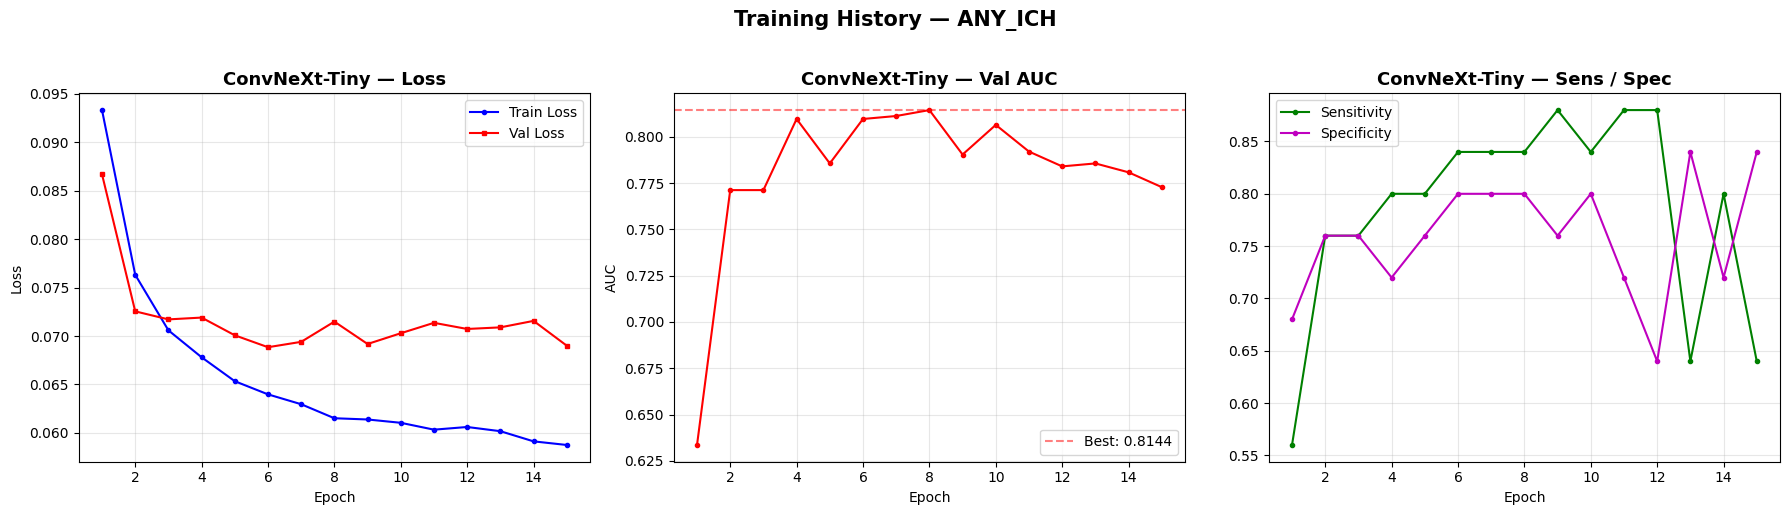

In [18]:
# =====================
# Training History — ConvNeXt-Tiny
# =====================
df_hist = pd.DataFrame(all_histories["convnext_tiny"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(df_hist["epoch"], df_hist["loss"], "b-o", markersize=3, label="Train Loss")
if "val_loss" in df_hist.columns:
    axes[0].plot(df_hist["epoch"], df_hist["val_loss"], "r-s", markersize=3, label="Val Loss")
axes[0].set_title("ConvNeXt-Tiny — Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# AUC
best_auc = max(df_hist["auc"])
axes[1].plot(df_hist["epoch"], df_hist["auc"], "r-o", markersize=3)
axes[1].axhline(y=best_auc, color="r", linestyle="--", alpha=0.5, label=f"Best: {best_auc:.4f}")
axes[1].set_title("ConvNeXt-Tiny — Val AUC", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Sensitivity & Specificity
axes[2].plot(df_hist["epoch"], df_hist["sensitivity"], "g-o", markersize=3, label="Sensitivity")
axes[2].plot(df_hist["epoch"], df_hist["specificity"], "m-o", markersize=3, label="Specificity")
axes[2].set_title("ConvNeXt-Tiny — Sens / Spec", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Training History — {EXPERIMENT_NAME.upper()}", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [19]:
def load_best_model(backbone_name, experiment_name, device):
    
    model = ICHModel(backbone_name, dropout=0.4)
    
    checkpoint_path = f"/kaggle/working/checkpoints/{experiment_name}/{backbone_name}_best.pt"
    
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    
    # Handle DataParallel prefix if present
    if list(state_dict.keys())[0].startswith("module."):
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    
    model = model.to(device)
    model.load_state_dict(state_dict)
    model.eval()
    
    print(f"Loaded best model from: {checkpoint_path}")
    return model

In [20]:
# ============================================================
# Evaluate ALL backbones on Test Set
# ============================================================
all_test_metrics = {}   # {backbone_name: metrics_dict}

_, _, test_loader = build_loaders(EXPERIMENT_NAME, splits, CACHE_ROOT, batch_size=BATCH_SIZE)

for bb_name in BACKBONE_NAMES:
    
    print(f"\n{'='*50}")
    print(f"  TEST: {bb_name.upper()} on {EXPERIMENT_NAME.upper()}")
    print(f"{'='*50}")
    
    model = load_best_model(bb_name, EXPERIMENT_NAME, DEVICE)
    metrics = validate_patient_level_test(model, test_loader, DEVICE)
    
    all_test_metrics[bb_name] = metrics
    
    print(f"  AUC:          {metrics['auc']:.4f}")
    print(f"  Sensitivity:  {metrics['sensitivity']:.4f}")
    print(f"  Specificity:  {metrics['specificity']:.4f}")
    print(f"  PPV:          {metrics['ppv']:.4f}")
    print(f"  NPV:          {metrics['npv']:.4f}")
    print(f"  Accuracy:     {metrics['accuracy']:.4f}")
    print(f"  Threshold:    {metrics['threshold']:.4f}")

print(f"\n{'='*50}")
print(f"All {len(BACKBONE_NAMES)} backbones evaluated on {EXPERIMENT_NAME.upper()}.")
print(f"{'='*50}")

  [any_ich] Train: 72526 slices (35077 pos, 37449 neg) | Val: 14720 | Test: 15223

  TEST: CONVNEXT_TINY on ANY_ICH
Loaded best model from: /kaggle/working/checkpoints/any_ich/convnext_tiny_best.pt
  AUC:          0.8561
  Sensitivity:  0.6667
  Specificity:  1.0000
  PPV:          1.0000
  NPV:          0.7333
  Accuracy:     0.8261
  Threshold:    0.6889

All 1 backbones evaluated on ANY_ICH.


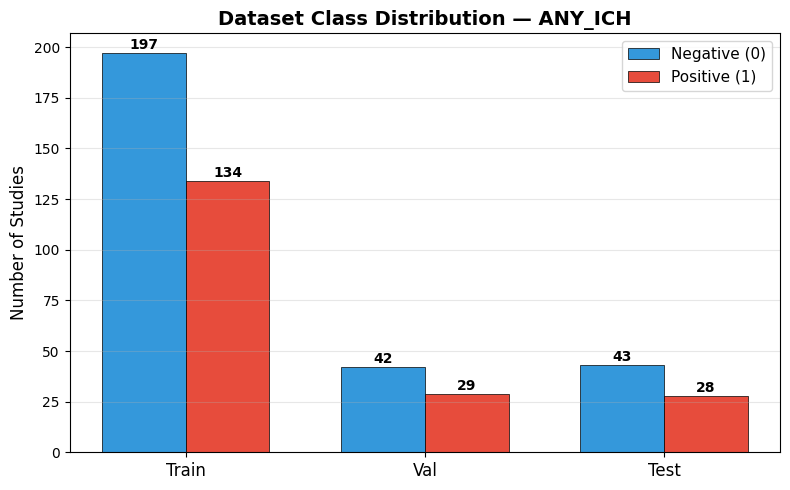

In [21]:
# ============================================================
# Fig. 1 — Dataset Class Distribution (Single Experiment)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

subsets = ["train", "val", "test"]
pos_counts = []
neg_counts = []
for s in subsets:
    df_s = splits[EXPERIMENT_NAME][s]
    pos_counts.append(int(df_s["label"].sum()))
    neg_counts.append(int(len(df_s) - df_s["label"].sum()))

x = np.arange(len(subsets))
w = 0.35
bars_neg = ax.bar(x - w/2, neg_counts, w, label="Negative (0)", color="#3498db", edgecolor="black", linewidth=0.5)
bars_pos = ax.bar(x + w/2, pos_counts, w, label="Positive (1)", color="#e74c3c", edgecolor="black", linewidth=0.5)

for bar in bars_neg:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars_pos:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(["Train", "Val", "Test"], fontsize=12)
ax.set_ylabel("Number of Studies", fontsize=12)
ax.set_title(f"Dataset Class Distribution — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# AUC with 95% Confidence Interval (Bootstrap) — ConvNeXt-Tiny
# ============================================================
from sklearn.utils import resample

def bootstrap_auc(y_true, y_pred, n_bootstraps=1000, seed=42):
    """Compute AUC with 95% CI using bootstrap resampling."""
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_true), len(y_true))
        y_t = y_true[idx]
        y_p = y_pred[idx]
        if len(np.unique(y_t)) < 2:
            continue
        aucs.append(roc_auc_score(y_t, y_p))
    aucs = np.array(aucs)
    return np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

# Compute CI for ConvNeXt-Tiny
ci_results = {}
m = all_test_metrics["convnext_tiny"]
mean_auc, ci_low, ci_high = bootstrap_auc(m["y_true"], m["y_pred"])
ci_results["convnext_tiny"] = {"mean": mean_auc, "ci_low": ci_low, "ci_high": ci_high}

print(f"{'='*60}")
print(f"  ConvNeXt-Tiny AUC with 95% Bootstrap CI — {EXPERIMENT_NAME.upper()}")
print(f"{'='*60}")
print(f"  AUC: {mean_auc:.4f}  (95% CI: {ci_low:.4f} – {ci_high:.4f})")
print(f"{'='*60}")


  ConvNeXt-Tiny AUC with 95% Bootstrap CI — ANY_ICH
  AUC: 0.8526  (95% CI: 0.7333 – 0.9490)


In [23]:
# ============================================================
# Training Statistics Summary — ConvNeXt-Tiny
# ============================================================
df_h = pd.DataFrame(all_histories["convnext_tiny"])

best_epoch = int(df_h.loc[df_h["auc"].idxmax(), "epoch"])
total_epochs = len(df_h)

print(f"\n{'='*60}")
print(f"  Training Statistics — ConvNeXt-Tiny ({EXPERIMENT_NAME.upper()})")
print(f"{'='*60}")
print(f"  Total Epochs:   {total_epochs}")
print(f"  Best Epoch:     {best_epoch}")
print(f"  Final Loss:     {df_h.iloc[-1]['loss']:.4f}")
print(f"  Best Val AUC:   {df_h['auc'].max():.4f}")
print(f"  Final Train Acc:{df_h.iloc[-1]['train_acc']:.4f}")
print(f"  Early Stopped:  {'Yes' if total_epochs < EPOCHS else 'No'}")
print(f"{'='*60}")



  Training Statistics — ConvNeXt-Tiny (ANY_ICH)
  Total Epochs:   15
  Best Epoch:     8
  Final Loss:     0.0588
  Best Val AUC:   0.8144
  Final Train Acc:0.6515
  Early Stopped:  Yes


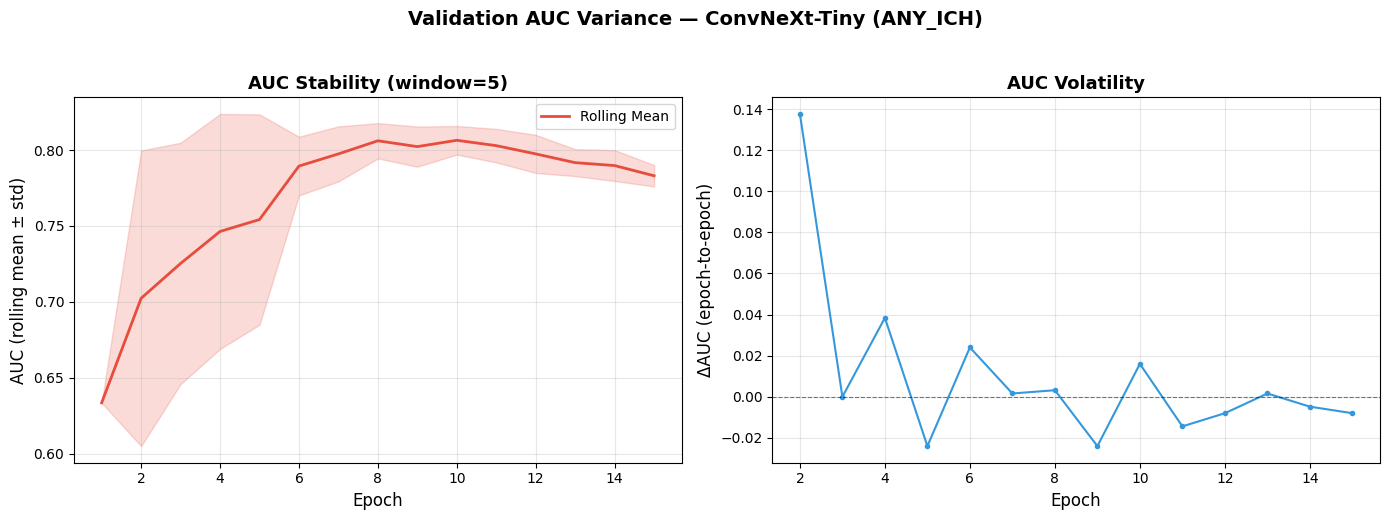


  AUC Statistics — ConvNeXt-Tiny
  Mean:  0.7812
  Std:   0.0421
  Var:   0.001770
  Min:   0.6336
  Max:   0.8144
  Range: 0.1808
  Best:  0.8144 (epoch 8)


In [24]:
# ==============================================================
# Validation AUC Variance & Stability — ConvNeXt-Tiny
# ==============================================================

aucs = np.array([h["auc"] for h in all_histories["convnext_tiny"]])
epochs = np.arange(1, len(aucs) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Rolling mean ± std ---
window = 5
rolling_mean = pd.Series(aucs).rolling(window=window, min_periods=1).mean().values
rolling_std = pd.Series(aucs).rolling(window=window, min_periods=1).std().fillna(0).values

axes[0].plot(epochs, rolling_mean, color="#e74c3c", linewidth=2, label="Rolling Mean")
axes[0].fill_between(epochs, rolling_mean - rolling_std, rolling_mean + rolling_std,
                     alpha=0.2, color="#e74c3c")
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("AUC (rolling mean ± std)", fontsize=12)
axes[0].set_title(f"AUC Stability (window={window})", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# --- Right: Epoch-to-epoch ΔAUC ---
if len(aucs) > 1:
    delta = np.diff(aucs)
    axes[1].plot(range(2, len(aucs) + 1), delta, color="#3498db", linewidth=1.5,
                 marker='o', markersize=3)
    axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("ΔAUC (epoch-to-epoch)", fontsize=12)
axes[1].set_title("AUC Volatility", fontsize=13, fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Validation AUC Variance — ConvNeXt-Tiny ({EXPERIMENT_NAME.upper()})",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\n{'='*50}")
print(f"  AUC Statistics — ConvNeXt-Tiny")
print(f"{'='*50}")
print(f"  Mean:  {np.mean(aucs):.4f}")
print(f"  Std:   {np.std(aucs):.4f}")
print(f"  Var:   {np.var(aucs):.6f}")
print(f"  Min:   {np.min(aucs):.4f}")
print(f"  Max:   {np.max(aucs):.4f}")
print(f"  Range: {np.max(aucs) - np.min(aucs):.4f}")
print(f"  Best:  {np.max(aucs):.4f} (epoch {int(np.argmax(aucs)) + 1})")
print(f"{'='*50}")


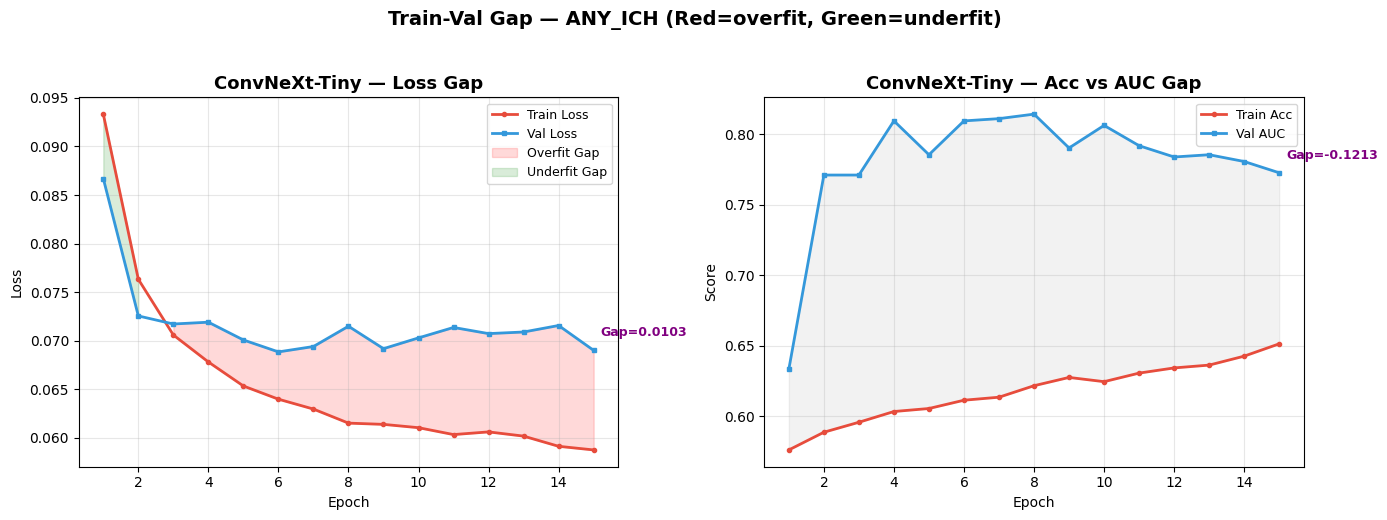


  Train-Val Gap at Final Epoch
  Train Loss:  0.0588
  Val Loss:    0.0690
  Loss Gap:    0.0103
  Train Acc:   0.6515
  Val AUC:     0.7728
  Acc-AUC Gap: -0.1213


In [25]:
# ==============================================================
# Train-Val Gap Analysis (Overfitting Diagnostic) — ConvNeXt-Tiny
# ==============================================================

df_h = pd.DataFrame(all_histories["convnext_tiny"])
epochs_plot = df_h["epoch"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_gap = {'train': '#e74c3c', 'val': '#3498db'}

# --- Left: Loss gap ---
ax1.plot(epochs_plot, df_h["loss"], label="Train Loss", color=colors_gap['train'],
         linewidth=2, marker='o', markersize=3)
if "val_loss" in df_h.columns:
    ax1.plot(epochs_plot, df_h["val_loss"], label="Val Loss", color=colors_gap['val'],
             linewidth=2, marker='s', markersize=3)
    gap = (df_h["val_loss"] - df_h["loss"]).values
    ax1.fill_between(epochs_plot, df_h["loss"], df_h["val_loss"],
                     where=gap > 0, alpha=0.15, color='red', label="Overfit Gap")
    ax1.fill_between(epochs_plot, df_h["loss"], df_h["val_loss"],
                     where=gap <= 0, alpha=0.15, color='green', label="Underfit Gap")
    ax1.annotate(f"Gap={gap[-1]:.4f}", xy=(epochs_plot.iloc[-1], df_h["val_loss"].iloc[-1]),
                 textcoords="offset points", xytext=(5, 10), fontsize=9, color='purple', fontweight='bold')

ax1.set_title("ConvNeXt-Tiny — Loss Gap", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# --- Right: Train Acc vs Val AUC ---
ax2.plot(epochs_plot, df_h["train_acc"], label="Train Acc", color=colors_gap['train'],
         linewidth=2, marker='o', markersize=3)
ax2.plot(epochs_plot, df_h["auc"], label="Val AUC", color=colors_gap['val'],
         linewidth=2, marker='s', markersize=3)
ax2.fill_between(epochs_plot, df_h["train_acc"], df_h["auc"], alpha=0.1, color='gray')
final_gap = df_h["train_acc"].iloc[-1] - df_h["auc"].iloc[-1]
ax2.annotate(f"Gap={final_gap:+.4f}", xy=(epochs_plot.iloc[-1], df_h["auc"].iloc[-1]),
             textcoords="offset points", xytext=(5, 10), fontsize=9, color='purple', fontweight='bold')

ax2.set_title("ConvNeXt-Tiny — Acc vs AUC Gap", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle(f"Train-Val Gap — {EXPERIMENT_NAME.upper()} (Red=overfit, Green=underfit)",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Summary
print(f"\n{'='*50}")
print(f"  Train-Val Gap at Final Epoch")
print(f"{'='*50}")
print(f"  Train Loss:  {df_h['loss'].iloc[-1]:.4f}")
if "val_loss" in df_h.columns:
    print(f"  Val Loss:    {df_h['val_loss'].iloc[-1]:.4f}")
    print(f"  Loss Gap:    {(df_h['val_loss'].iloc[-1] - df_h['loss'].iloc[-1]):.4f}")
print(f"  Train Acc:   {df_h['train_acc'].iloc[-1]:.4f}")
print(f"  Val AUC:     {df_h['auc'].iloc[-1]:.4f}")
print(f"  Acc-AUC Gap: {final_gap:.4f}")
print(f"{'='*50}")


In [26]:
# ==============================================================
# MACHINE LEARNING BASELINE — LightGBM with Radiomics Features
# ==============================================================
# This section extracts handcrafted radiomics features from CT slices
# and trains a LightGBM classifier for ML vs Deep Learning comparison.
# ==============================================================

import lightgbm as lgb
from scipy import ndimage
from scipy.stats import skew, kurtosis, entropy
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import shannon_entropy
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

print("=" * 60)
print("  LightGBM + Radiomics — ML vs DL Comparison")
print("=" * 60)

# =====================
# Radiomics Feature Extraction
# =====================

def extract_first_order_features(img):
    """First-order (intensity histogram) features."""
    flat = img.flatten()
    features = {
        "mean": np.mean(flat),
        "std": np.std(flat),
        "variance": np.var(flat),
        "median": np.median(flat),
        "min": np.min(flat),
        "max": np.max(flat),
        "range": np.max(flat) - np.min(flat),
        "skewness": float(skew(flat)),
        "kurtosis": float(kurtosis(flat)),
        "energy": np.sum(flat ** 2),
        "entropy": float(shannon_entropy(img)),
        "p10": np.percentile(flat, 10),
        "p25": np.percentile(flat, 25),
        "p75": np.percentile(flat, 75),
        "p90": np.percentile(flat, 90),
        "iqr": np.percentile(flat, 75) - np.percentile(flat, 25),
        "mad": np.mean(np.abs(flat - np.mean(flat))),  # mean absolute deviation
        "rms": np.sqrt(np.mean(flat ** 2)),             # root mean square
        "uniformity": np.sum((np.histogram(flat, bins=64, density=True)[0]) ** 2),
    }
    # Non-zero region stats (foreground)
    nz = flat[flat > 0.05]
    if len(nz) > 10:
        features["nz_mean"] = np.mean(nz)
        features["nz_std"] = np.std(nz)
        features["nz_ratio"] = len(nz) / len(flat)
    else:
        features["nz_mean"] = 0.0
        features["nz_std"] = 0.0
        features["nz_ratio"] = 0.0
    return features


def extract_glcm_features(img, distances=[1, 3], angles=[0, np.pi/4, np.pi/2]):
    """Gray-Level Co-occurrence Matrix (GLCM) texture features."""
    # Quantize to 32 levels for GLCM
    img_uint = (np.clip(img, 0, 1) * 31).astype(np.uint8)
    
    features = {}
    try:
        glcm = graycomatrix(img_uint, distances=distances, angles=angles,
                            levels=32, symmetric=True, normed=True)
        
        for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]:
            vals = graycoprops(glcm, prop)
            features[f"glcm_{prop}_mean"] = float(np.mean(vals))
            features[f"glcm_{prop}_std"] = float(np.std(vals))
            features[f"glcm_{prop}_max"] = float(np.max(vals))
    except Exception:
        for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]:
            features[f"glcm_{prop}_mean"] = 0.0
            features[f"glcm_{prop}_std"] = 0.0
            features[f"glcm_{prop}_max"] = 0.0
    return features


def extract_lbp_features(img, radius=2, n_points=16):
    """Local Binary Pattern (LBP) texture features."""
    img_uint8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    
    features = {}
    try:
        lbp = local_binary_pattern(img_uint8, n_points, radius, method="uniform")
        n_bins = n_points + 2
        hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins), density=True)
        
        features["lbp_mean"] = float(np.mean(lbp))
        features["lbp_std"] = float(np.std(lbp))
        features["lbp_entropy"] = float(entropy(hist + 1e-10))
        features["lbp_uniformity"] = float(np.sum(hist ** 2))
        # Top 5 LBP histogram bins
        for k in range(min(5, len(hist))):
            features[f"lbp_hist_{k}"] = float(hist[k])
    except Exception:
        features["lbp_mean"] = 0.0
        features["lbp_std"] = 0.0
        features["lbp_entropy"] = 0.0
        features["lbp_uniformity"] = 0.0
        for k in range(5):
            features[f"lbp_hist_{k}"] = 0.0
    return features


def extract_gradient_features(img):
    """Gradient-based features (edge information)."""
    gx = ndimage.sobel(img, axis=0)
    gy = ndimage.sobel(img, axis=1)
    mag = np.hypot(gx, gy)
    
    features = {
        "grad_mean": float(np.mean(mag)),
        "grad_std": float(np.std(mag)),
        "grad_max": float(np.max(mag)),
        "grad_energy": float(np.sum(mag ** 2)),
        "grad_entropy": float(shannon_entropy(mag)),
    }
    return features


def extract_morphological_features(img, threshold=0.15):
    """Shape/morphological features from binary mask of bright regions."""
    binary = (img > threshold).astype(np.uint8)
    
    features = {}
    features["brain_area_ratio"] = float(np.sum(binary) / binary.size)
    
    # Connected components
    labeled, n_components = ndimage.label(binary)
    features["n_components"] = n_components
    
    if n_components > 0:
        component_sizes = ndimage.sum(binary, labeled, range(1, n_components + 1))
        features["largest_component_ratio"] = float(np.max(component_sizes) / binary.size)
        features["component_size_std"] = float(np.std(component_sizes)) if n_components > 1 else 0.0
    else:
        features["largest_component_ratio"] = 0.0
        features["component_size_std"] = 0.0
    
    return features


def extract_all_radiomics(img):
    """Extract complete radiomics feature vector from a single 2D slice."""
    features = {}
    features.update(extract_first_order_features(img))
    features.update(extract_glcm_features(img))
    features.update(extract_lbp_features(img))
    features.update(extract_gradient_features(img))
    features.update(extract_morphological_features(img))
    return features

print(f"✓ Radiomics feature extraction defined.")
print(f"  Feature categories: First-order, GLCM, LBP, Gradient, Morphological")

# Quick test: feature count
dummy = np.random.rand(224, 224).astype(np.float32)
dummy_feats = extract_all_radiomics(dummy)
print(f"  Total features per slice: {len(dummy_feats)}")
print(f"  Feature names: {list(dummy_feats.keys())[:10]}...")


  LightGBM + Radiomics — ML vs DL Comparison
✓ Radiomics feature extraction defined.
  Feature categories: First-order, GLCM, LBP, Gradient, Morphological
  Total features per slice: 55
  Feature names: ['mean', 'std', 'variance', 'median', 'min', 'max', 'range', 'skewness', 'kurtosis', 'energy']...


In [27]:
# ==============================================================
# Extract Radiomics Features — Study-Level Aggregation
# ==============================================================
# For each study: extract radiomics from ALL slices, then aggregate
# using mean, std, max, min, and percentiles across slices.
# This mirrors clinical practice: a radiologist looks at ALL slices.
# ==============================================================

def extract_study_radiomics(df, cache_root, max_slices_per_study=None):
    """
    Extract radiomics features for each study (patient).
    
    Per slice → extract all radiomics features
    Per study → aggregate: mean, std, max, min, p25, p75 across slices
    
    Returns: feature matrix X (n_studies × n_features), labels y, study_ids
    """
    study_features = []
    study_labels = []
    study_ids = []
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting radiomics"):
        study_id = row["study_id"]
        label = row["label"]
        
        study_dir = os.path.join(cache_root, study_id)
        if not os.path.exists(study_dir):
            continue
        
        npy_files = sorted([f for f in os.listdir(study_dir) if f.endswith(".npy")])
        
        if max_slices_per_study and len(npy_files) > max_slices_per_study:
            # Sample evenly spaced slices
            indices = np.linspace(0, len(npy_files) - 1, max_slices_per_study, dtype=int)
            npy_files = [npy_files[i] for i in indices]
        
        slice_feats_list = []
        for f in npy_files:
            img = np.load(os.path.join(study_dir, f)).astype(np.float32)
            feats = extract_all_radiomics(img)
            slice_feats_list.append(feats)
        
        if len(slice_feats_list) == 0:
            continue
        
        # Aggregate across slices
        df_slices = pd.DataFrame(slice_feats_list)
        agg = {}
        for col in df_slices.columns:
            vals = df_slices[col].values
            agg[f"{col}_mean"] = np.mean(vals)
            agg[f"{col}_std"] = np.std(vals)
            agg[f"{col}_max"] = np.max(vals)
            agg[f"{col}_min"] = np.min(vals)
            agg[f"{col}_p25"] = np.percentile(vals, 25)
            agg[f"{col}_p75"] = np.percentile(vals, 75)
        
        # Add slice count as a feature
        agg["n_slices"] = len(slice_feats_list)
        
        study_features.append(agg)
        study_labels.append(label)
        study_ids.append(study_id)
    
    X = pd.DataFrame(study_features).fillna(0).values
    y = np.array(study_labels)
    
    feature_names = list(pd.DataFrame(study_features).columns)
    
    return X, y, study_ids, feature_names


# Extract features for train, val, test
print(f"\nExtracting radiomics for: {EXPERIMENT_NAME.upper()}")
print("-" * 60)

X_train, y_train, ids_train, feature_names = extract_study_radiomics(
    splits[EXPERIMENT_NAME]["train"], CACHE_ROOT, max_slices_per_study=30
)
X_val, y_val, ids_val, _ = extract_study_radiomics(
    splits[EXPERIMENT_NAME]["val"], CACHE_ROOT, max_slices_per_study=30
)
X_test, y_test, ids_test, _ = extract_study_radiomics(
    splits[EXPERIMENT_NAME]["test"], CACHE_ROOT, max_slices_per_study=30
)

print(f"\n{'='*60}")
print(f"  Radiomics Feature Extraction Complete")
print(f"{'='*60}")
print(f"  Train: {X_train.shape[0]} studies × {X_train.shape[1]} features")
print(f"  Val:   {X_val.shape[0]} studies × {X_val.shape[1]} features")
print(f"  Test:  {X_test.shape[0]} studies × {X_test.shape[1]} features")
print(f"  Train class balance: {int(y_train.sum())} pos / {int(len(y_train) - y_train.sum())} neg")
print(f"  Feature categories: First-order(6agg) + GLCM(6agg) + LBP(6agg) + Gradient(6agg) + Morpho(6agg)")



Extracting radiomics for: ANY_ICH
------------------------------------------------------------


Extracting radiomics: 100%|██████████| 71/71 [00:47<00:00,  1.50it/s]


  Radiomics Feature Extraction Complete
  Train: 227 studies × 331 features
  Val:   50 studies × 331 features
  Test:  46 studies × 331 features
  Train class balance: 104 pos / 123 neg
  Feature categories: First-order(6agg) + GLCM(6agg) + LBP(6agg) + Gradient(6agg) + Morpho(6agg)


In [28]:
# ==============================================================
# Train LightGBM with Hyperparameter Tuning
# ==============================================================

from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Compute class weight (scale_pos_weight for imbalanced data)
n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
scale_pos_weight = n_neg / max(n_pos, 1)

print(f"Class balance: {n_pos} pos / {n_neg} neg → scale_pos_weight = {scale_pos_weight:.2f}")

# =====================
# LightGBM with manual hyperparameter search
# Reduced to 3 configs (removed 1000-estimator heavy config) +
# early stopping tightened to 30 rounds for speed
# =====================
param_grid = [
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.05, "num_leaves": 31,
     "min_child_samples": 10, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 1.0},
    {"n_estimators": 800, "max_depth": 7, "learning_rate": 0.03, "num_leaves": 63,
     "min_child_samples": 5, "subsample": 0.7, "colsample_bytree": 0.7, "reg_alpha": 0.5, "reg_lambda": 2.0},
    {"n_estimators": 600, "max_depth": 4, "learning_rate": 0.05, "num_leaves": 15,
     "min_child_samples": 15, "subsample": 0.85, "colsample_bytree": 0.9, "reg_alpha": 0.01, "reg_lambda": 0.5},
]

best_val_auc = 0.0
best_params = None
best_lgb_model = None

print(f"\nHyperparameter search ({len(param_grid)} configurations)...")
print("-" * 60)

for idx, params in enumerate(param_grid):
    model_lgb = lgb.LGBMClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        verbose=-1,
        n_jobs=-1,
        boosting_type="gbdt",
        objective="binary",
    )
    
    model_lgb.fit(
        X_train_scaled, y_train,
        eval_set=[(X_val_scaled, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),  # tighter: 30 rounds
            lgb.log_evaluation(period=0)
        ]
    )
    
    y_val_prob = model_lgb.predict_proba(X_val_scaled)[:, 1]
    
    if len(np.unique(y_val)) >= 2:
        val_auc = roc_auc_score(y_val, y_val_prob)
    else:
        val_auc = 0.5
    
    print(f"  Config {idx+1}: Val AUC = {val_auc:.4f} | "
          f"depth={params.get('max_depth', -1)}, lr={params['learning_rate']}, "
          f"n_est={model_lgb.best_iteration_ if hasattr(model_lgb, 'best_iteration_') else params['n_estimators']}")
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_params = params
        best_lgb_model = model_lgb

print(f"\n{'='*60}")
print(f"  Best LightGBM Val AUC: {best_val_auc:.4f}")
print(f"  Best params: {best_params}")
print(f"{'='*60}")

# =====================
# Evaluate on Test Set
# =====================
y_test_prob_lgb = best_lgb_model.predict_proba(X_test_scaled)[:, 1]

if len(np.unique(y_test)) >= 2:
    lgb_auc = roc_auc_score(y_test, y_test_prob_lgb)
    fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, y_test_prob_lgb)
    youden_idx = np.argmax(tpr_lgb - fpr_lgb)
    optimal_threshold_lgb = thresholds_lgb[youden_idx]
else:
    lgb_auc = 0.5
    optimal_threshold_lgb = 0.5

y_test_binary_lgb = (y_test_prob_lgb >= optimal_threshold_lgb).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_test_binary_lgb).ravel()

lgb_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
lgb_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
lgb_ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
lgb_npv = tn / (tn + fn) if (tn + fn) > 0 else 0
lgb_accuracy = accuracy_score(y_test, y_test_binary_lgb)

# Store in same format as DL metrics
lgb_test_metrics = {
    "auc": lgb_auc,
    "sensitivity": lgb_sensitivity,
    "specificity": lgb_specificity,
    "ppv": lgb_ppv,
    "npv": lgb_npv,
    "accuracy": lgb_accuracy,
    "threshold": optimal_threshold_lgb,
    "y_true": y_test,
    "y_pred": y_test_prob_lgb,
}

# Add to all_test_metrics for unified comparison
all_test_metrics["lightgbm_radiomics"] = lgb_test_metrics

print(f"\n{'='*60}")
print(f"  LightGBM + Radiomics — TEST Results ({EXPERIMENT_NAME.upper()})")
print(f"{'='*60}")
print(f"  AUC:          {lgb_auc:.4f}")
print(f"  Sensitivity:  {lgb_sensitivity:.4f}")
print(f"  Specificity:  {lgb_specificity:.4f}")
print(f"  PPV:          {lgb_ppv:.4f}")
print(f"  NPV:          {lgb_npv:.4f}")
print(f"  Accuracy:     {lgb_accuracy:.4f}")
print(f"  Threshold:    {optimal_threshold_lgb:.4f}")
print(f"{'='*60}")


Class balance: 104 pos / 123 neg → scale_pos_weight = 1.18

Hyperparameter search (3 configurations)...
------------------------------------------------------------
  Config 1: Val AUC = 0.6976 | depth=5, lr=0.05, n_est=23


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Config 2: Val AUC = 0.7248 | depth=7, lr=0.03, n_est=90
  Config 3: Val AUC = 0.7472 | depth=4, lr=0.05, n_est=52

  Best LightGBM Val AUC: 0.7472
  Best params: {'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.05, 'num_leaves': 15, 'min_child_samples': 15, 'subsample': 0.85, 'colsample_bytree': 0.9, 'reg_alpha': 0.01, 'reg_lambda': 0.5}

  LightGBM + Radiomics — TEST Results (ANY_ICH)
  AUC:          0.6042
  Sensitivity:  0.5417
  Specificity:  0.9091
  PPV:          0.8667
  NPV:          0.6452
  Accuracy:     0.7174
  Threshold:    0.5310


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


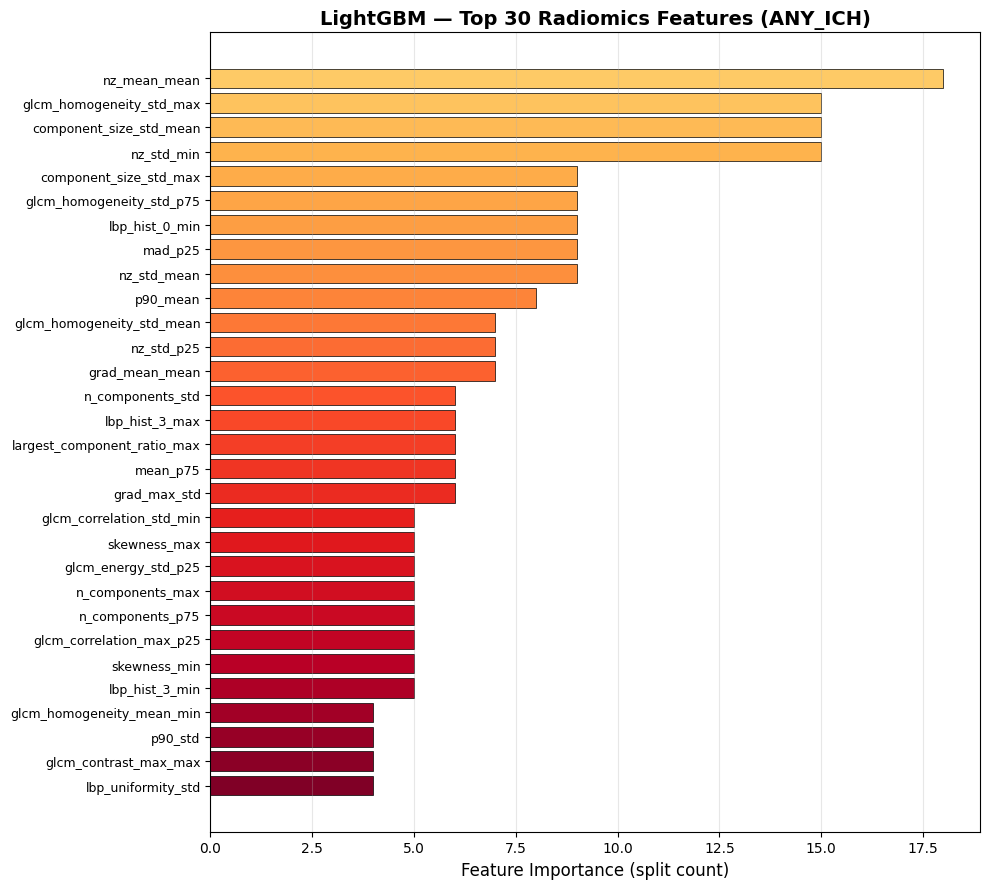


Feature importance by category:
----------------------------------------
  First-Order       :      128 ( 32.8%)
  GLCM              :      118 ( 30.3%)
  LBP               :       62 ( 15.9%)
  Morphological     :       53 ( 13.6%)
  Gradient          :       29 (  7.4%)
  Other             :        0 (  0.0%)


In [29]:
# ==============================================================
# Fig. 17 — LightGBM Feature Importance (Top 30)
# ==============================================================

importances = best_lgb_model.feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = min(30, len(feat_imp))
top_feats = feat_imp.head(top_n)

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.3)))
colors_imp = plt.cm.YlOrRd(np.linspace(0.3, 1.0, top_n))[::-1]
ax.barh(range(top_n), top_feats["importance"].values[::-1],
        color=colors_imp, edgecolor="black", linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats["feature"].values[::-1], fontsize=9)
ax.set_xlabel("Feature Importance (split count)", fontsize=12)
ax.set_title(f"LightGBM — Top {top_n} Radiomics Features ({EXPERIMENT_NAME.upper()})",
             fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# Categorize features
categories = {"First-Order": 0, "GLCM": 0, "LBP": 0, "Gradient": 0, "Morphological": 0, "Other": 0}
for _, row in feat_imp.iterrows():
    fname = row["feature"]
    imp = row["importance"]
    if any(k in fname for k in ["glcm_"]):
        categories["GLCM"] += imp
    elif any(k in fname for k in ["lbp_"]):
        categories["LBP"] += imp
    elif any(k in fname for k in ["grad_"]):
        categories["Gradient"] += imp
    elif any(k in fname for k in ["brain_area", "n_components", "largest_component", "component_size"]):
        categories["Morphological"] += imp
    elif any(k in fname for k in ["n_slices"]):
        categories["Other"] += imp
    else:
        categories["First-Order"] += imp

print(f"\nFeature importance by category:")
print("-" * 40)
total_imp = sum(categories.values())
for cat, imp in sorted(categories.items(), key=lambda x: -x[1]):
    print(f"  {cat:18s}: {imp:8.0f} ({100*imp/total_imp:5.1f}%)")


In [30]:
# ==============================================================
# TABLE 4 — Complete ML vs DL Comparison
# ==============================================================
from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef

ALL_METHODS = BACKBONE_NAMES + ["lightgbm_radiomics"]
METHOD_LABELS = {b: b.upper() for b in BACKBONE_NAMES}
METHOD_LABELS["lightgbm_radiomics"] = "LightGBM (Radiomics)"

# Bootstrap AUC CI for LightGBM
def bootstrap_auc(y_true, y_pred, n_bootstraps=1000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_true), len(y_true))
        y_t = y_true[idx]
        y_p = y_pred[idx]
        if len(np.unique(y_t)) < 2:
            continue
        aucs.append(roc_auc_score(y_t, y_p))
    aucs = np.array(aucs)
    return np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

# Add LightGBM CI
lgb_ci_mean, lgb_ci_low, lgb_ci_high = bootstrap_auc(y_test, y_test_prob_lgb)
ci_results["lightgbm_radiomics"] = {"mean": lgb_ci_mean, "ci_low": lgb_ci_low, "ci_high": lgb_ci_high}

comparison_rows = []
for method in ALL_METHODS:
    m = all_test_metrics[method]
    ci = ci_results[method]
    y_bin = (m["y_pred"] >= m["threshold"]).astype(int)
    
    f1 = f1_score(m["y_true"], y_bin)
    bal_acc = balanced_accuracy_score(m["y_true"], y_bin)
    mcc = matthews_corrcoef(m["y_true"], y_bin)
    ap = average_precision_score(m["y_true"], m["y_pred"])
    j_stat = m["sensitivity"] + m["specificity"] - 1
    
    approach = "Machine Learning" if method == "lightgbm_radiomics" else "Deep Learning"
    
    comparison_rows.append({
        "Method": METHOD_LABELS[method],
        "Approach": approach,
        "AUC": f"{ci['mean']:.4f}",
        "95% CI": f"[{ci['ci_low']:.4f}–{ci['ci_high']:.4f}]",
        "Sens": f"{m['sensitivity']:.4f}",
        "Spec": f"{m['specificity']:.4f}",
        "PPV": f"{m['ppv']:.4f}",
        "NPV": f"{m['npv']:.4f}",
        "F1": f"{f1:.4f}",
        "Bal Acc": f"{bal_acc:.4f}",
        "MCC": f"{mcc:.4f}",
        "AP": f"{ap:.4f}",
        "Youden J": f"{j_stat:.4f}",
    })

df_comparison = pd.DataFrame(comparison_rows)

print("=" * 130)
print(f"  TABLE 4: Machine Learning vs Deep Learning — Complete Comparison ({EXPERIMENT_NAME.upper()})")
print("=" * 130)
display(df_comparison.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('font-size', '11px')]}
]).apply(lambda x: ['background-color: #fff3cd' if v == 'Machine Learning' else '' 
                     for v in df_comparison['Approach']], axis=0))


  TABLE 4: Machine Learning vs Deep Learning — Complete Comparison (ANY_ICH)


,Method,Approach,AUC,95% CI,Sens,Spec,PPV,NPV,F1,Bal Acc,MCC,AP,Youden J
0,CONVNEXT_TINY,Deep Learning,0.8526,[0.7333–0.9490],0.6667,1.0000,1.0000,0.7333,0.8000,0.8333,0.6992,0.8979,0.6667
1,LightGBM (Radiomics),Machine Learning,0.5987,[0.4259–0.7848],0.5417,0.9091,0.8667,0.6452,0.6667,0.7254,0.4803,0.6516,0.4508


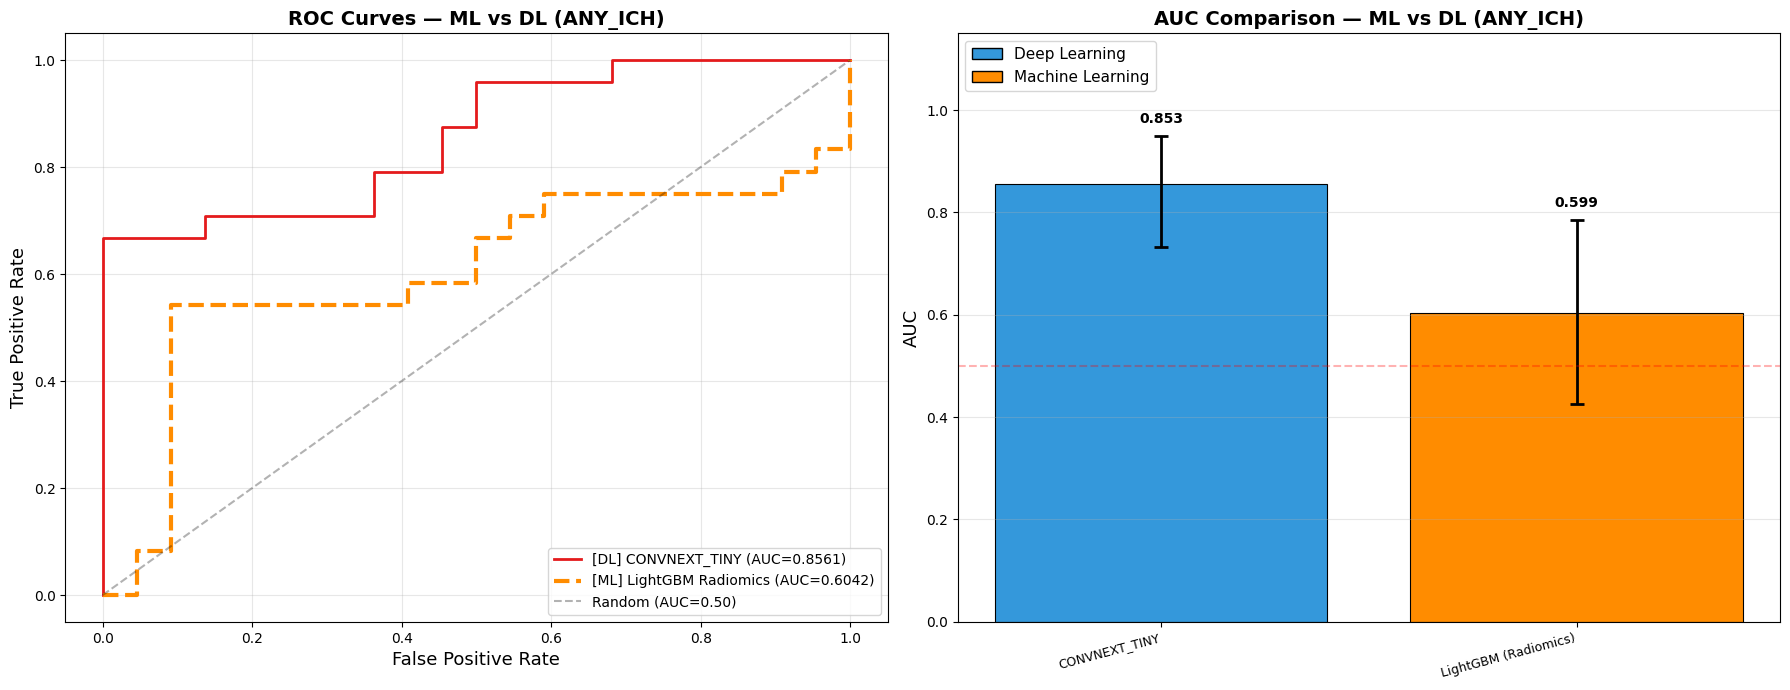

In [31]:
# ==============================================================
# Fig. 18 — ML vs DL: ROC Curves Overlay
# ==============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: ROC Curves ---
dl_colors = plt.cm.Set1(np.linspace(0, 0.6, len(BACKBONE_NAMES)))
ml_color = "#FF8C00"  # Orange for ML

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_pred"])
    ax1.plot(fpr, tpr, color=dl_colors[i], linewidth=2,
             label=f"[DL] {bb_name.upper()} (AUC={m['auc']:.4f})")

# LightGBM
m_lgb = all_test_metrics["lightgbm_radiomics"]
fpr_lgb, tpr_lgb, _ = roc_curve(m_lgb["y_true"], m_lgb["y_pred"])
ax1.plot(fpr_lgb, tpr_lgb, color=ml_color, linewidth=3, linestyle="--",
         label=f"[ML] LightGBM Radiomics (AUC={m_lgb['auc']:.4f})")

ax1.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random (AUC=0.50)")
ax1.set_xlabel("False Positive Rate", fontsize=13)
ax1.set_ylabel("True Positive Rate", fontsize=13)
ax1.set_title(f"ROC Curves — ML vs DL ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Right: AUC Bar Chart with approach grouping ---
methods = ALL_METHODS
auc_vals = [all_test_metrics[m]["auc"] for m in methods]
labels = [METHOD_LABELS[m] for m in methods]
bar_colors = ["#3498db"] * len(BACKBONE_NAMES) + ["#FF8C00"]

bars = ax2.bar(range(len(methods)), auc_vals, color=bar_colors,
               edgecolor="black", linewidth=0.8)

# Add CI whiskers
for i, method in enumerate(methods):
    ci = ci_results[method]
    ax2.errorbar(i, ci["mean"], 
                 yerr=[[ci["mean"] - ci["ci_low"]], [ci["ci_high"] - ci["mean"]]],
                 color="black", capsize=5, capthick=2, linewidth=2, fmt="none")
    ax2.text(i, ci["ci_high"] + 0.02, f"{ci['mean']:.3f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(labels, fontsize=9, rotation=15, ha="right")
ax2.set_ylabel("AUC", fontsize=13)
ax2.set_title(f"AUC Comparison — ML vs DL ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax2.set_ylim(0, 1.15)
ax2.axhline(y=0.5, color="red", linestyle="--", alpha=0.3)
ax2.grid(axis="y", alpha=0.3)

# Legend for approach
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#3498db", edgecolor="black", label="Deep Learning"),
                   Patch(facecolor="#FF8C00", edgecolor="black", label="Machine Learning")]
ax2.legend(handles=legend_elements, fontsize=11, loc="upper left")

plt.tight_layout()
plt.show()


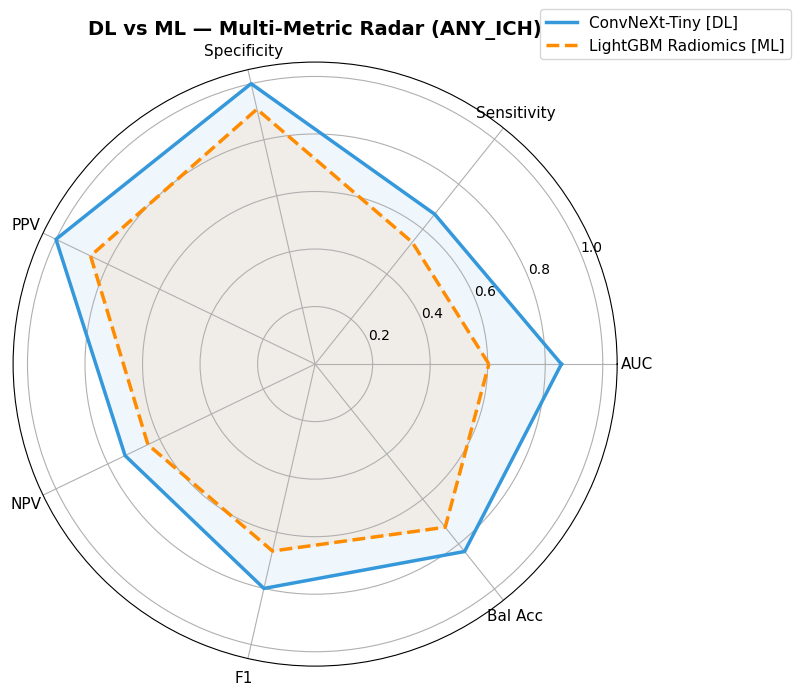

In [32]:
# ==============================================================
# Radar Chart: ConvNeXt-Tiny (DL) vs LightGBM (ML)
# ==============================================================
from sklearn.metrics import f1_score, balanced_accuracy_score

metric_names = ["AUC", "Sensitivity", "Specificity", "PPV", "NPV", "F1", "Bal Acc"]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, polar=True)

angles = np.linspace(0, 2 * np.pi, len(metric_names), endpoint=False).tolist()
angles += angles[:1]

for method, color, ls, lw, label in [
    ("convnext_tiny", "#3498db", "-", 2.5, "ConvNeXt-Tiny [DL]"),
    ("lightgbm_radiomics", "#FF8C00", "--", 2.5, "LightGBM Radiomics [ML]"),
]:
    m = all_test_metrics[method]
    y_bin = (m["y_pred"] >= m["threshold"]).astype(int)
    values = [
        m["auc"], m["sensitivity"], m["specificity"], m["ppv"], m["npv"],
        f1_score(m["y_true"], y_bin), balanced_accuracy_score(m["y_true"], y_bin),
    ]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=lw, linestyle=ls, label=label)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title(f"DL vs ML — Multi-Metric Radar ({EXPERIMENT_NAME.upper()})",
             fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()


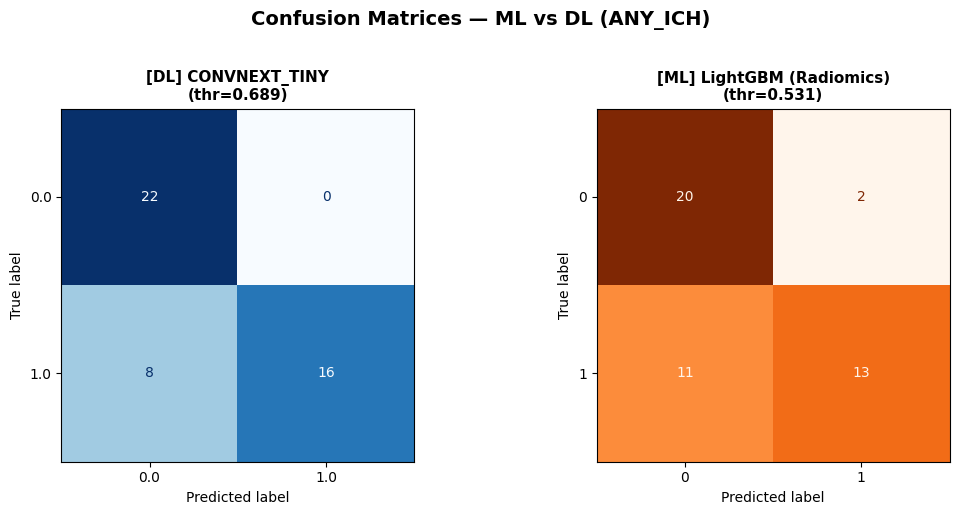

In [33]:
# ==============================================================
# Fig. 20 — Confusion Matrices: ML vs DL (All Methods)
# ==============================================================
from sklearn.metrics import ConfusionMatrixDisplay

n_methods = len(ALL_METHODS)
n_cols = min(4, n_methods)
n_rows = int(np.ceil(n_methods / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for i, method in enumerate(ALL_METHODS):
    m = all_test_metrics[method]
    threshold = m["threshold"]
    y_pred_binary = (m["y_pred"] >= threshold).astype(int)
    
    cmap = "Oranges" if method == "lightgbm_radiomics" else "Blues"
    
    ConfusionMatrixDisplay.from_predictions(
        m["y_true"], y_pred_binary, ax=axes[i],
        cmap=cmap, colorbar=False
    )
    
    label = METHOD_LABELS[method]
    tag = "[ML]" if method == "lightgbm_radiomics" else "[DL]"
    axes[i].set_title(f"{tag} {label}\n(thr={threshold:.3f})", fontsize=11, fontweight="bold")

for j in range(n_methods, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Confusion Matrices — ML vs DL ({EXPERIMENT_NAME.upper()})",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [34]:
# ==============================================================
# DeLong's Test — ConvNeXt-Tiny (DL) vs LightGBM (ML)
# ==============================================================
from scipy.stats import norm

def delong_roc_variance(y_true, y_pred):
    n1 = np.sum(y_true == 1)
    n0 = np.sum(y_true == 0)
    pos_preds = y_pred[y_true == 1]
    neg_preds = y_pred[y_true == 0]
    V10 = np.array([np.mean(pos_preds > n) + 0.5 * np.mean(pos_preds == n) for n in neg_preds])
    V01 = np.array([np.mean(neg_preds < p) + 0.5 * np.mean(neg_preds == p) for p in pos_preds])
    S10 = np.var(V10, ddof=1) if len(V10) > 1 else 0
    S01 = np.var(V01, ddof=1) if len(V01) > 1 else 0
    return S10 / n0 + S01 / n1

def delong_test(y_true, y_pred_a, y_pred_b):
    auc_a = roc_auc_score(y_true, y_pred_a)
    auc_b = roc_auc_score(y_true, y_pred_b)
    var_a = delong_roc_variance(y_true, y_pred_a)
    var_b = delong_roc_variance(y_true, y_pred_b)
    n1, n0 = np.sum(y_true == 1), np.sum(y_true == 0)
    V01_a = np.array([np.mean(y_pred_a[y_true == 0] < p) + 0.5 * np.mean(y_pred_a[y_true == 0] == p) for p in y_pred_a[y_true == 1]])
    V01_b = np.array([np.mean(y_pred_b[y_true == 0] < p) + 0.5 * np.mean(y_pred_b[y_true == 0] == p) for p in y_pred_b[y_true == 1]])
    V10_a = np.array([np.mean(y_pred_a[y_true == 1] > n) + 0.5 * np.mean(y_pred_a[y_true == 1] == n) for n in y_pred_a[y_true == 0]])
    V10_b = np.array([np.mean(y_pred_b[y_true == 1] > n) + 0.5 * np.mean(y_pred_b[y_true == 1] == n) for n in y_pred_b[y_true == 0]])
    cov01 = np.cov(V01_a, V01_b)[0, 1] if len(V01_a) > 1 else 0
    cov10 = np.cov(V10_a, V10_b)[0, 1] if len(V10_a) > 1 else 0
    var_diff = max(var_a + var_b - 2 * (cov10 / n0 + cov01 / n1), 1e-10)
    z = (auc_a - auc_b) / np.sqrt(var_diff)
    p_value = 2 * (1 - norm.cdf(abs(z)))
    return auc_a, auc_b, z, p_value

# Run test
lgb_m = all_test_metrics["lightgbm_radiomics"]
dl_m = all_test_metrics["convnext_tiny"]
auc_lgb, auc_dl, z_stat, p_val = delong_test(lgb_m["y_true"], lgb_m["y_pred"], dl_m["y_pred"])

sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
delta = auc_dl - auc_lgb

print(f"\n{'='*70}")
print(f"  DeLong's Test: ConvNeXt-Tiny vs LightGBM ({EXPERIMENT_NAME.upper()})")
print(f"{'='*70}")
print(f"  AUC (DL - ConvNeXt):  {auc_dl:.4f}")
print(f"  AUC (ML - LightGBM):  {auc_lgb:.4f}")
print(f"  ΔAUC (DL − ML):       {delta:+.4f}")
print(f"  z-statistic:          {z_stat:.3f}")
print(f"  p-value:              {p_val:.4f}" if p_val >= 0.0001 else f"  p-value:              {p_val:.2e}")
print(f"  Significance:         {sig}")
print(f"  Winner:               {'DL' if delta > 0 and p_val < 0.05 else ('ML' if delta < 0 and p_val < 0.05 else 'No significant difference')}")
print(f"{'='*70}")



  DeLong's Test: ConvNeXt-Tiny vs LightGBM (ANY_ICH)
  AUC (DL - ConvNeXt):  0.8561
  AUC (ML - LightGBM):  0.6042
  ΔAUC (DL − ML):       +0.2519
  z-statistic:          -2.864
  p-value:              0.0042
  Significance:         **
  Winner:               DL


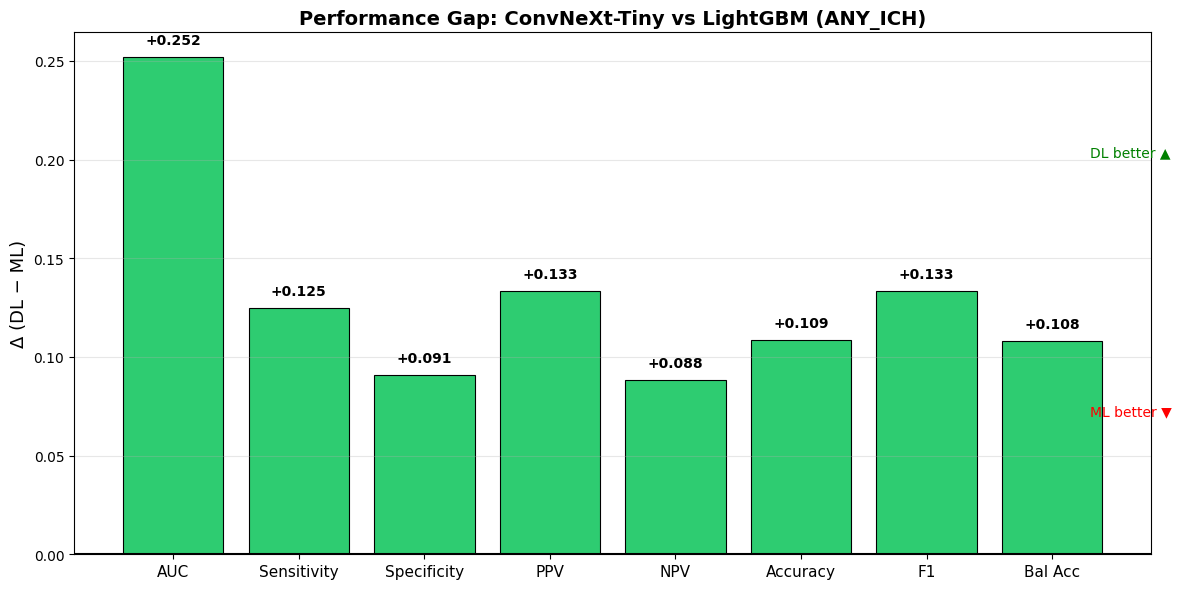


  Quantitative Gap — DL vs ML (ANY_ICH)


,Metric,ConvNeXt-Tiny (DL),LightGBM (ML),Δ (DL − ML)
0,AUC,0.8561,0.6042,+0.2519
1,Sensitivity,0.6667,0.5417,+0.1250
2,Specificity,1.0000,0.9091,+0.0909
3,PPV,1.0000,0.8667,+0.1333
4,NPV,0.7333,0.6452,+0.0882
5,Accuracy,0.8261,0.7174,+0.1087
6,F1,0.8000,0.6667,+0.1333
7,Bal Acc,0.8333,0.7254,+0.1080



  ΔAUC = +0.2519
  → Deep Learning SIGNIFICANTLY outperforms ML baseline


In [35]:
# ==============================================================
# Quantitative Gap Analysis: ConvNeXt-Tiny (DL) vs LightGBM (ML)
# ==============================================================
from sklearn.metrics import f1_score, balanced_accuracy_score

dl_m = all_test_metrics["convnext_tiny"]
ml_m = all_test_metrics["lightgbm_radiomics"]
dl_bin = (dl_m["y_pred"] >= dl_m["threshold"]).astype(int)
ml_bin = (ml_m["y_pred"] >= ml_m["threshold"]).astype(int)

metric_names_gap = ["AUC", "Sensitivity", "Specificity", "PPV", "NPV", "Accuracy", "F1", "Bal Acc"]
dl_vals = [dl_m["auc"], dl_m["sensitivity"], dl_m["specificity"], dl_m["ppv"], dl_m["npv"],
           dl_m["accuracy"], f1_score(dl_m["y_true"], dl_bin), balanced_accuracy_score(dl_m["y_true"], dl_bin)]
ml_vals = [ml_m["auc"], ml_m["sensitivity"], ml_m["specificity"], ml_m["ppv"], ml_m["npv"],
           ml_m["accuracy"], f1_score(ml_m["y_true"], ml_bin), balanced_accuracy_score(ml_m["y_true"], ml_bin)]
deltas = [d - m for d, m in zip(dl_vals, ml_vals)]

# --- Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metric_names_gap))
colors = ["#2ecc71" if d >= 0 else "#e74c3c" for d in deltas]

bars = ax.bar(x, deltas, color=colors, edgecolor="black", linewidth=0.8)
for bar, d in zip(bars, deltas):
    y_pos = bar.get_height() + 0.005 if d >= 0 else bar.get_height() - 0.015
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos, f"{d:+.3f}",
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=10, fontweight='bold')

ax.axhline(y=0, color="black", linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(metric_names_gap, fontsize=11)
ax.set_ylabel("Δ (DL − ML)", fontsize=13)
ax.set_title(f"Performance Gap: ConvNeXt-Tiny vs LightGBM ({EXPERIMENT_NAME.upper()})",
             fontsize=14, fontweight="bold")
ax.text(len(metric_names_gap) - 0.7, max(deltas) * 0.8, "DL better ▲", fontsize=10, color="green")
ax.text(len(metric_names_gap) - 0.7, min(deltas) * 0.8, "ML better ▼", fontsize=10, color="red")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Summary Table ---
gap_df = pd.DataFrame({
    "Metric": metric_names_gap,
    "ConvNeXt-Tiny (DL)": [f"{v:.4f}" for v in dl_vals],
    "LightGBM (ML)": [f"{v:.4f}" for v in ml_vals],
    "Δ (DL − ML)": [f"{d:+.4f}" for d in deltas],
})
print(f"\n{'='*70}")
print(f"  Quantitative Gap — DL vs ML ({EXPERIMENT_NAME.upper()})")
print(f"{'='*70}")
display(gap_df.style.set_properties(**{
    'text-align': 'center', 'font-size': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))

# Verdict
gap_auc = dl_m["auc"] - ml_m["auc"]
print(f"\n  ΔAUC = {gap_auc:+.4f}")
if gap_auc > 0.05:
    print(f"  → Deep Learning SIGNIFICANTLY outperforms ML baseline")
elif gap_auc > 0.02:
    print(f"  → Deep Learning moderately outperforms ML baseline")
elif gap_auc > -0.02:
    print(f"  → Performance is COMPARABLE (marginal difference)")
else:
    print(f"  → Machine Learning outperforms DL")


In [36]:
import pickle

print("\n✓ Training finished! Saving results...")

with open('all_histories.pkl', 'wb') as f:
    pickle.dump(all_histories, f)

with open('all_test_metrics.pkl', 'wb') as f:
    pickle.dump(all_test_metrics, f)

with open('lightgbm_model.pkl', 'wb') as f:
    pickle.dump(best_lgb_model, f)

with open('radiomics_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

summary = {
    'date': pd.Timestamp.now(),
    'experiment': EXPERIMENT_NAME,
    'methods': ['convnext_tiny', 'lightgbm_radiomics'],
    'epochs': EPOCHS,
    'convnext_auc': all_test_metrics['convnext_tiny']['auc'],
    'lightgbm_auc': all_test_metrics['lightgbm_radiomics']['auc'],
}
with open('summary.pkl', 'wb') as f:
    pickle.dump(summary, f)

print("✓ All results saved!")



✓ Training finished! Saving results...
✓ All results saved!



---

## 📈 Learning Curve & Data Efficiency Analysis — DL vs ML

Analisis ini mengukur bagaimana performa **ConvNeXt-Tiny (DL)** vs **LightGBM Radiomics (ML)** berubah seiring bertambahnya jumlah data training.

| Metrik | Deskripsi |
|---|---|
| **AUC per Proporsi Data** | Kurva AUC pada setiap subset ukuran training (10% – 100%) |
| **∆AUC (DL − ML)** | Selisih AUC antara DL dan ML di setiap titik data |
| **Crossover Point (n\*)** | Titik di mana DL mulai mengungguli ML secara konsisten |
| **Relative Improvement (%)** | Seberapa besar peningkatan DL terhadap ML secara relatif |
| **Data Efficiency** | Berapa persen data yang dibutuhkan masing-masing model untuk mencapai 95% dari AUC penuh |


In [37]:

# ==============================================================
# LEARNING CURVE — AUC per Proporsi Data (DL vs ML)
# ==============================================================
# Trains ConvNeXt-Tiny and LightGBM at increasing proportions of
# training data: 25%, 50%, 75%, 100%.
# Validation is always done on the full val set for a fair comparison.
#
# Speed optimisations vs original:
#   • Only 4 proportions instead of 10
#   • LC_EPOCHS reduced to 5 (from 8) — lightweight per-subset training
#   • Sub-loader slices capped at LC_MAX_SLICES (5 000) per proportion
# ==============================================================

from sklearn.utils import resample as sk_resample

# ── Config ──────────────────────────────────────────────────
PROPORTIONS   = [0.25, 0.50, 0.75, 1.00]  # 4 checkpoints: 25 / 50 / 75 / 100 %
LC_EPOCHS     = 5                          # lightweight DL training per subset
LC_MAX_SLICES = 5000                       # max slices fed to DL per proportion

# Ambil train dataframe
train_df_full = splits[EXPERIMENT_NAME]["train"].copy().reset_index(drop=True)
n_total_studies = len(train_df_full)

lc_results = []  # list of dicts: {proportion, n_studies, auc_dl, auc_ml}

print(f"Learning Curve: {EXPERIMENT_NAME.upper()}")
print(f"Total train studies : {n_total_studies}")
print(f"Proportions         : {[f'{p:.0%}' for p in PROPORTIONS]}")
print(f"LC epochs per subset: {LC_EPOCHS}")
print(f"Max slices per LC   : {LC_MAX_SLICES}")
print("=" * 70)

for prop in PROPORTIONS:
    n_studies = max(int(n_total_studies * prop), 4)  # min 4 studies
    
    # Stratified subsample (maintain class ratio)
    pos_df = train_df_full[train_df_full["label"] == 1]
    neg_df = train_df_full[train_df_full["label"] == 0]
    
    n_pos = max(1, int(len(pos_df) * prop))
    n_neg = max(1, int(len(neg_df) * prop))
    
    sub_pos = pos_df.iloc[:n_pos]
    sub_neg = neg_df.iloc[:n_neg]
    sub_df = pd.concat([sub_pos, sub_neg]).reset_index(drop=True)
    
    actual_n = len(sub_df)
    
    # -----------------------------------------------
    # ML: LightGBM on radiomics subset
    # -----------------------------------------------
    X_sub_r, y_sub_r, _, _ = extract_study_radiomics(
        sub_df, CACHE_ROOT, max_slices_per_study=30
    )
    
    scaler_sub = StandardScaler()
    X_sub_scaled = scaler_sub.fit_transform(X_sub_r)
    X_val_sc = scaler_sub.transform(X_val)
    
    n_pos_sub = int(y_sub_r.sum())
    n_neg_sub = int(len(y_sub_r) - n_pos_sub)
    spw = n_neg_sub / max(n_pos_sub, 1)
    
    ml_sub = lgb.LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        num_leaves=31, min_child_samples=max(1, min(10, n_pos_sub - 1)),
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, random_state=SEED,
        verbose=-1, n_jobs=-1
    )
    
    try:
        ml_sub.fit(
            X_sub_scaled, y_sub_r,
            eval_set=[(X_val_sc, y_val)],
            callbacks=[lgb.early_stopping(30, verbose=False),
                       lgb.log_evaluation(period=0)]
        )
        y_val_prob_ml = ml_sub.predict_proba(X_val_sc)[:, 1]
        auc_ml = roc_auc_score(y_val, y_val_prob_ml) if len(np.unique(y_val)) >= 2 else 0.5
    except Exception as e:
        print(f"  [ML] Error at prop={prop:.0%}: {e}")
        auc_ml = 0.5
    
    # -----------------------------------------------
    # DL: ConvNeXt-Tiny — lightweight training per subset
    # Slices capped at LC_MAX_SLICES for speed
    # -----------------------------------------------
    seed_everything(SEED)
    
    sub_dl_dataset = CachedSliceDataset(
        sub_df, CACHE_ROOT, augment=True, normalize=True,
        max_slices=LC_MAX_SLICES          # ← cap slices per LC step
    )
    
    labels_sub = [s[1] for s in sub_dl_dataset.samples]
    n_p = max(sum(labels_sub), 1)
    n_n = max(len(labels_sub) - n_p, 1)
    w_p = len(labels_sub) / (2.0 * n_p)
    w_n = len(labels_sub) / (2.0 * n_n)
    sw = [w_p if l == 1 else w_n for l in labels_sub]
    
    sub_sampler = WeightedRandomSampler(sw, min(len(sw), 1000), replacement=True)
    sub_loader = DataLoader(sub_dl_dataset, batch_size=16, sampler=sub_sampler,
                            num_workers=2, pin_memory=True, drop_last=False)
    
    # val loader (shared, full val set — no cap)
    val_dataset_lc = CachedSliceDataset(
        splits[EXPERIMENT_NAME]["val"], CACHE_ROOT, augment=False, normalize=True
    )
    val_loader_lc = DataLoader(val_dataset_lc, batch_size=32, shuffle=False,
                               num_workers=2, pin_memory=True)
    
    model_lc = ICHModel("convnext_tiny", dropout=0.4).to(DEVICE)
    criterion_lc = FocalLoss(alpha=0.75, gamma=2.0, label_smoothing=0.05)
    optimizer_lc = torch.optim.AdamW(model_lc.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scaler_lc = GradScaler()
    
    for ep in range(LC_EPOCHS):
        model_lc.train()
        for imgs, lbls, _ in sub_loader:
            imgs = imgs.to(DEVICE)
            lbls = lbls.unsqueeze(1).to(DEVICE)
            optimizer_lc.zero_grad()
            with autocast():
                logits = model_lc(imgs)
                loss = criterion_lc(logits, lbls)
            scaler_lc.scale(loss).backward()
            scaler_lc.step(optimizer_lc)
            scaler_lc.update()
    
    # Evaluate on full val set
    model_lc.eval()
    slice_dict_lc = defaultdict(list)
    labels_lc = {}
    with torch.no_grad():
        for imgs, lbls, sids in val_loader_lc:
            imgs = imgs.to(DEVICE)
            probs_lc = torch.sigmoid(model_lc(imgs)).cpu().numpy().flatten()
            for i in range(len(probs_lc)):
                slice_dict_lc[sids[i]].append(probs_lc[i])
                labels_lc[sids[i]] = lbls[i].item()
    
    y_true_lc, y_pred_lc = [], []
    for sid in slice_dict_lc:
        preds = np.array(slice_dict_lc[sid])
        k = max(1, int(len(preds) * 0.10))
        top_k = np.mean(np.sort(preds)[-k:])
        sw2 = np.exp(np.linspace(0, 2, len(np.sort(preds))))
        ewm = np.average(np.sort(preds), weights=sw2)
        y_pred_lc.append(0.6 * top_k + 0.4 * ewm)
        y_true_lc.append(labels_lc[sid])
    
    y_true_lc = np.array(y_true_lc)
    y_pred_lc = np.array(y_pred_lc)
    
    try:
        auc_dl = roc_auc_score(y_true_lc, y_pred_lc) if len(np.unique(y_true_lc)) >= 2 else 0.5
    except Exception:
        auc_dl = 0.5
    
    lc_results.append({
        "proportion": prop,
        "n_studies": actual_n,
        "auc_dl": auc_dl,
        "auc_ml": auc_ml,
        "delta_auc": auc_dl - auc_ml,
        "relative_improvement": (auc_dl - auc_ml) / max(auc_ml, 1e-6) * 100,
    })
    
    print(f"  prop={prop:.0%} | n={actual_n:3d} studies | "
          f"AUC_DL={auc_dl:.4f} | AUC_ML={auc_ml:.4f} | "
          f"ΔAUC={auc_dl - auc_ml:+.4f}")

lc_df = pd.DataFrame(lc_results)
print(f"\n✓ Learning curve computed ({len(lc_df)} data points).")
print(lc_df.to_string(index=False))


Learning Curve: ANY_ICH
Total train studies : 331
Proportions         : ['25%', '50%', '75%', '100%']
LC epochs per subset: 5
Max slices per LC   : 5000


Extracting radiomics: 100%|██████████| 82/82 [00:58<00:00,  1.39it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    [CachedSliceDataset] Capped to 5000 slices (from 5000 total)


/tmp/ipykernel_24/722050935.py:118: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_lc = GradScaler()
/tmp/ipykernel_24/722050935.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  prop=25% | n= 82 studies | AUC_DL=0.6080 | AUC_ML=0.4912 | ΔAUC=+0.1168


...

  prop=75% | n=247 studies | AUC_DL=0.7760 | AUC_ML=0.6416 | ΔAUC=+0.1344


Extracting radiomics: 100%|██████████| 331/331 [03:49<00:00,  1.44it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    [CachedSliceDataset] Capped to 5000 slices (from 5000 total)


/tmp/ipykernel_24/722050935.py:118: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_lc = GradScaler()
/tmp/ipykernel_24/722050935.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  prop=100% | n=331 studies | AUC_DL=0.6352 | AUC_ML=0.7392 | ΔAUC=-0.1040

✓ Learning curve computed (4 data points).
 proportion  n_studies  auc_dl  auc_ml  delta_auc  relative_improvement
       0.25         82  0.6080  0.4912     0.1168             23.778502
       0.50        165  0.7632  0.6096     0.1536             25.196850
       0.75        247  0.7760  0.6416     0.1344             20.947631
       1.00        331  0.6352  0.7392    -0.1040            -14.069264


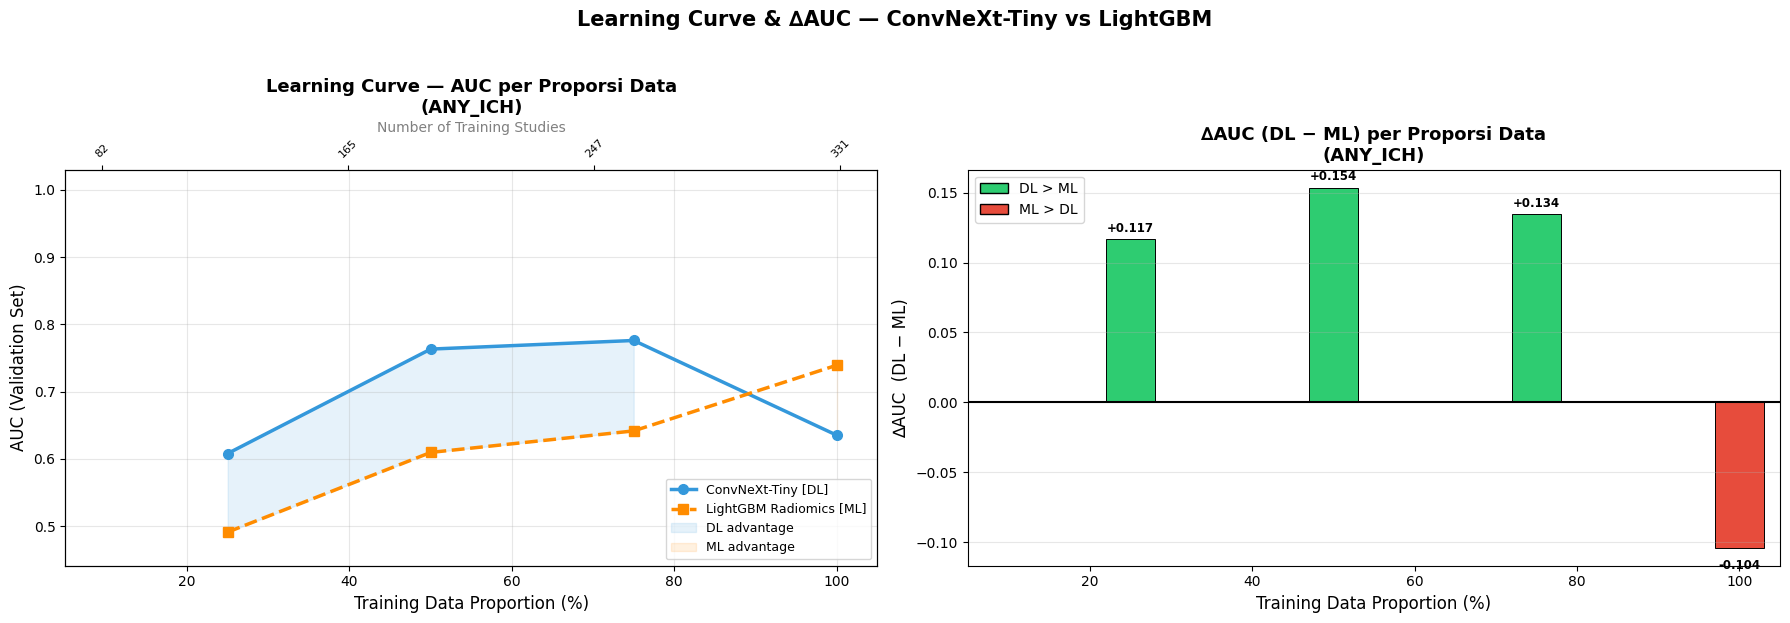

In [38]:

# ==============================================================
# Fig. LC-1 — AUC per Proporsi Data (Learning Curve) + ∆AUC
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

props_pct = lc_df["proportion"] * 100
n_studies = lc_df["n_studies"]

# ── Left: AUC Learning Curves ──────────────────────────────
ax = axes[0]
ax.plot(props_pct, lc_df["auc_dl"], color="#3498db", linewidth=2.5,
        marker="o", markersize=7, label="ConvNeXt-Tiny [DL]", zorder=3)
ax.plot(props_pct, lc_df["auc_ml"], color="#FF8C00", linewidth=2.5,
        linestyle="--", marker="s", markersize=7, label="LightGBM Radiomics [ML]", zorder=3)

# Shaded gap between curves
ax.fill_between(props_pct, lc_df["auc_dl"], lc_df["auc_ml"],
                where=(lc_df["auc_dl"] >= lc_df["auc_ml"]),
                alpha=0.12, color="#3498db", label="DL advantage")
ax.fill_between(props_pct, lc_df["auc_dl"], lc_df["auc_ml"],
                where=(lc_df["auc_dl"] < lc_df["auc_ml"]),
                alpha=0.12, color="#FF8C00", label="ML advantage")

# Crossover point annotation (n*)
deltas = lc_df["delta_auc"].values
crossover_idx = None
for i in range(len(deltas) - 1):
    if deltas[i] <= 0 and deltas[i + 1] > 0:
        crossover_idx = i + 1
        break

if crossover_idx is not None:
    n_star = lc_df.iloc[crossover_idx]["n_studies"]
    p_star = lc_df.iloc[crossover_idx]["proportion"] * 100
    ax.axvline(x=p_star, color="purple", linestyle=":", linewidth=1.8,
               label=f"Crossover n*={int(n_star)} studies ({p_star:.0f}%)")
    ax.annotate(f"n* = {int(n_star)}", xy=(p_star, lc_df.iloc[crossover_idx]["auc_dl"]),
                xytext=(p_star + 3, lc_df.iloc[crossover_idx]["auc_dl"] - 0.03),
                fontsize=10, color="purple", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="purple", lw=1.5))

# Secondary x-axis: n_studies
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(props_pct)
ax2.set_xticklabels([str(int(n)) for n in n_studies], fontsize=8, rotation=45)
ax2.set_xlabel("Number of Training Studies", fontsize=10, color="gray")

ax.set_xlabel("Training Data Proportion (%)", fontsize=12)
ax.set_ylabel("AUC (Validation Set)", fontsize=12)
ax.set_title(f"Learning Curve — AUC per Proporsi Data\n({EXPERIMENT_NAME.upper()})",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.set_ylim(max(0.4, lc_df[["auc_dl", "auc_ml"]].min().min() - 0.05), 1.03)
ax.grid(True, alpha=0.3)
ax.set_xlim(5, 105)

# ── Right: ∆AUC (DL − ML) per Proporsi ─────────────────────
ax3 = axes[1]
bar_colors = ["#2ecc71" if d >= 0 else "#e74c3c" for d in lc_df["delta_auc"]]
bars = ax3.bar(props_pct, lc_df["delta_auc"], width=6, color=bar_colors,
               edgecolor="black", linewidth=0.7)

for bar, d, n in zip(bars, lc_df["delta_auc"], n_studies):
    y_off = 0.003 if d >= 0 else -0.008
    va = "bottom" if d >= 0 else "top"
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_off,
             f"{d:+.3f}", ha="center", va=va, fontsize=8.5, fontweight="bold")

ax3.axhline(y=0, color="black", linewidth=1.5)
if crossover_idx is not None:
    ax3.axvline(x=p_star, color="purple", linestyle=":", linewidth=1.8,
                label=f"Crossover at {p_star:.0f}%")
    ax3.legend(fontsize=10)

ax3.set_xlabel("Training Data Proportion (%)", fontsize=12)
ax3.set_ylabel("∆AUC  (DL − ML)", fontsize=12)
ax3.set_title(f"∆AUC (DL − ML) per Proporsi Data\n({EXPERIMENT_NAME.upper()})",
              fontsize=13, fontweight="bold")
ax3.set_xlim(5, 105)
ax3.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor="#2ecc71", edgecolor="black", label="DL > ML"),
              Patch(facecolor="#e74c3c", edgecolor="black", label="ML > DL")]
ax3.legend(handles=legend_els, fontsize=10, loc="upper left")

plt.suptitle("Learning Curve & ∆AUC — ConvNeXt-Tiny vs LightGBM",
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


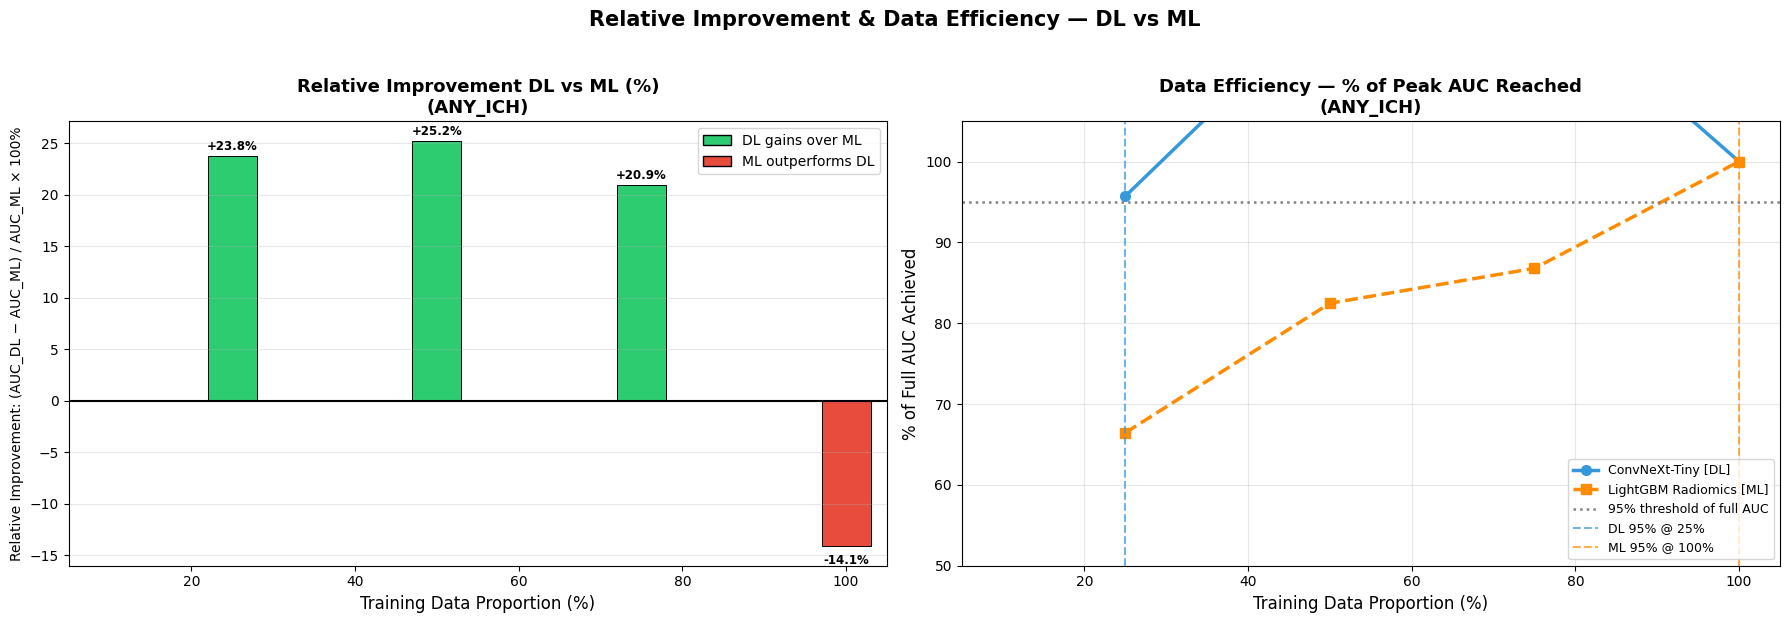


  Data Efficiency Summary — ANY_ICH
  DL (ConvNeXt-Tiny)  — Full AUC (100% data): 0.6352
  ML (LightGBM)       — Full AUC (100% data): 0.7392
  DL reaches 95% of peak AUC at: 25% of training data
  ML reaches 95% of peak AUC at: 100% of training data


In [39]:

# ==============================================================
# Fig. LC-2 — Relative Improvement (%) + Data Efficiency
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Left: Relative Improvement (%) ──────────────────────────
ax4 = axes[0]
rel_imp = lc_df["relative_improvement"].values
bar_colors_rel = ["#2ecc71" if r >= 0 else "#e74c3c" for r in rel_imp]

bars_rel = ax4.bar(props_pct, rel_imp, width=6, color=bar_colors_rel,
                   edgecolor="black", linewidth=0.7)

for bar, r in zip(bars_rel, rel_imp):
    y_off = 0.3 if r >= 0 else -0.8
    va = "bottom" if r >= 0 else "top"
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_off,
             f"{r:+.1f}%", ha="center", va=va, fontsize=8.5, fontweight="bold")

ax4.axhline(y=0, color="black", linewidth=1.5)
ax4.set_xlabel("Training Data Proportion (%)", fontsize=12)
ax4.set_ylabel("Relative Improvement: (AUC_DL − AUC_ML) / AUC_ML × 100%", fontsize=10)
ax4.set_title(f"Relative Improvement DL vs ML (%)\n({EXPERIMENT_NAME.upper()})",
              fontsize=13, fontweight="bold")
ax4.set_xlim(5, 105)
ax4.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_ri = [Patch(facecolor="#2ecc71", edgecolor="black", label="DL gains over ML"),
             Patch(facecolor="#e74c3c", edgecolor="black", label="ML outperforms DL")]
ax4.legend(handles=legend_ri, fontsize=10)

# ── Right: Data Efficiency (95% of Full AUC) ────────────────
ax5 = axes[1]

# Compute 95% of the full AUC (at 100% data)
full_auc_dl = lc_df[lc_df["proportion"] == 1.00]["auc_dl"].values[0]
full_auc_ml = lc_df[lc_df["proportion"] == 1.00]["auc_ml"].values[0]

threshold_dl_95 = 0.95 * full_auc_dl
threshold_ml_95 = 0.95 * full_auc_ml

# Find the first proportion where each model reaches 95% of its full AUC
eff_dl = lc_df[lc_df["auc_dl"] >= threshold_dl_95]["proportion"].min()
eff_ml = lc_df[lc_df["auc_ml"] >= threshold_ml_95]["proportion"].min()

ax5.plot(props_pct, lc_df["auc_dl"] / full_auc_dl * 100, color="#3498db",
         linewidth=2.5, marker="o", markersize=7, label="ConvNeXt-Tiny [DL]")
ax5.plot(props_pct, lc_df["auc_ml"] / full_auc_ml * 100, color="#FF8C00",
         linewidth=2.5, linestyle="--", marker="s", markersize=7,
         label="LightGBM Radiomics [ML]")

ax5.axhline(y=95, color="gray", linestyle=":", linewidth=1.8,
            label="95% threshold of full AUC")

if not np.isnan(eff_dl):
    ax5.axvline(x=eff_dl * 100, color="#3498db", linestyle="--", linewidth=1.5,
                alpha=0.7, label=f"DL 95% @ {eff_dl:.0%}")
if not np.isnan(eff_ml):
    ax5.axvline(x=eff_ml * 100, color="#FF8C00", linestyle="--", linewidth=1.5,
                alpha=0.7, label=f"ML 95% @ {eff_ml:.0%}")

ax5.set_xlabel("Training Data Proportion (%)", fontsize=12)
ax5.set_ylabel("% of Full AUC Achieved", fontsize=12)
ax5.set_title(f"Data Efficiency — % of Peak AUC Reached\n({EXPERIMENT_NAME.upper()})",
              fontsize=13, fontweight="bold")
ax5.set_xlim(5, 105)
ax5.set_ylim(50, 105)
ax5.legend(fontsize=9, loc="lower right")
ax5.grid(True, alpha=0.3)

plt.suptitle("Relative Improvement & Data Efficiency — DL vs ML",
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# ── Summary printout
print(f"\n{'='*70}")
print(f"  Data Efficiency Summary — {EXPERIMENT_NAME.upper()}")
print(f"{'='*70}")
print(f"  DL (ConvNeXt-Tiny)  — Full AUC (100% data): {full_auc_dl:.4f}")
print(f"  ML (LightGBM)       — Full AUC (100% data): {full_auc_ml:.4f}")
print(f"  DL reaches 95% of peak AUC at: {eff_dl:.0%} of training data")
print(f"  ML reaches 95% of peak AUC at: {eff_ml:.0%} of training data")
print(f"{'='*70}")


In [40]:

# ==============================================================
# TABLE LC — Ringkasan Lengkap Learning Curve Analysis
# AUC per Proporsi | ∆AUC | Crossover n* | Relative Improvement
# ==============================================================

# ── Crossover point
crossover_prop = None
crossover_n = None
for i in range(len(lc_df) - 1):
    if lc_df.iloc[i]["delta_auc"] <= 0 and lc_df.iloc[i + 1]["delta_auc"] > 0:
        crossover_prop = lc_df.iloc[i + 1]["proportion"]
        crossover_n = int(lc_df.iloc[i + 1]["n_studies"])
        break

# ── Build summary table
lc_table = lc_df.copy()
lc_table["proportion_pct"] = (lc_table["proportion"] * 100).astype(int).astype(str) + "%"
lc_table["auc_dl_fmt"] = lc_table["auc_dl"].map(lambda x: f"{x:.4f}")
lc_table["auc_ml_fmt"] = lc_table["auc_ml"].map(lambda x: f"{x:.4f}")
lc_table["delta_fmt"] = lc_table["delta_auc"].map(lambda x: f"{x:+.4f}")
lc_table["rel_imp_fmt"] = lc_table["relative_improvement"].map(lambda x: f"{x:+.2f}%")
lc_table["winner"] = lc_table["delta_auc"].apply(
    lambda d: "✅ DL" if d > 0.005 else ("🔶 ML" if d < -0.005 else "≈ Tie")
)

display_df = lc_table[["proportion_pct", "n_studies", "auc_dl_fmt", "auc_ml_fmt",
                         "delta_fmt", "rel_imp_fmt", "winner"]].rename(columns={
    "proportion_pct": "Proporsi",
    "n_studies":      "N Studies",
    "auc_dl_fmt":     "AUC (DL)",
    "auc_ml_fmt":     "AUC (ML)",
    "delta_fmt":      "∆AUC (DL−ML)",
    "rel_imp_fmt":    "Rel. Improvement",
    "winner":         "Unggul"
})

print("=" * 80)
print(f"  TABLE LC: Learning Curve Analysis — {EXPERIMENT_NAME.upper()}")
print("=" * 80)
display(display_df.style
    .set_properties(**{"text-align": "center", "font-size": "12px"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
    ])
    .apply(lambda col: [
        "background-color: #d4edda" if "✅" in str(v)
        else "background-color: #fff3cd" if "🔶" in str(v)
        else ""
        for v in col
    ], subset=["Unggul"])
)

# ── Crossover Point printout ─────────────────────────────────
print(f"\n{'='*70}")
print(f"  🔀 Crossover Point (n*) — Titik DL Mulai Unggul")
print(f"{'='*70}")
if crossover_n is not None:
    print(f"  n* = {crossover_n} studies ({crossover_prop:.0%} of training data)")
    print(f"  → DL mulai konsisten mengungguli ML setelah n* studies")
else:
    # Check if DL is always better or always worse
    if (lc_df["delta_auc"] > 0).all():
        print(f"  DL SELALU unggul dari ML di semua proporsi data (tidak ada crossover)")
    elif (lc_df["delta_auc"] < 0).all():
        print(f"  ML SELALU unggul dari DL di semua proporsi data (tidak ada crossover)")
    else:
        print(f"  Crossover tidak terdeteksi dengan jelas (fluktuasi kecil)")

# ── Practical Guideline ──────────────────────────────────────
full_delta = lc_df.iloc[-1]["delta_auc"]
full_rel = lc_df.iloc[-1]["relative_improvement"]
mean_delta = lc_df["delta_auc"].mean()

print(f"\n{'='*70}")
print(f"  📋 Panduan Praktis — {EXPERIMENT_NAME.upper()}")
print(f"{'='*70}")
print(f"  ∆AUC pada data penuh (100%): {full_delta:+.4f}")
print(f"  Relative Improvement (100%): {full_rel:+.2f}%")
print(f"  Rata-rata ∆AUC:              {mean_delta:+.4f}")
print()

if full_delta > 0.05:
    rec = "SANGAT DISARANKAN menggunakan DL (ConvNeXt-Tiny)"
    reason = f"DL lebih unggul {full_delta:.4f} AUC ({full_rel:.1f}%) di atas ML."
elif full_delta > 0.02:
    rec = "DISARANKAN menggunakan DL, terutama jika data cukup"
    reason = f"DL lebih baik secara moderat (+{full_delta:.4f} AUC)."
elif full_delta > -0.02:
    rec = "SEBANDING: ML cukup memadai, DL memberikan gain marginal"
    reason = f"Selisih AUC sangat kecil ({full_delta:+.4f}), ML lebih efisien secara komputasi."
else:
    rec = "DISARANKAN menggunakan ML (LightGBM) untuk dataset ini"
    reason = f"ML mengungguli DL ({full_delta:.4f} AUC). DL membutuhkan lebih banyak data."

print(f"  Rekomendasi: {rec}")
print(f"  Alasan:      {reason}")

if crossover_n is not None:
    print(f"\n  ⚠ Jika jumlah data < {crossover_n} studies → gunakan LightGBM (ML)")
    print(f"    Jika jumlah data ≥ {crossover_n} studies → ConvNeXt-Tiny (DL) lebih optimal")

eff_dl_pct = f"{eff_dl:.0%}" if not np.isnan(eff_dl) else "N/A"
eff_ml_pct = f"{eff_ml:.0%}" if not np.isnan(eff_ml) else "N/A"
print(f"\n  Data Efficiency:")
print(f"    DL mencapai 95% peak AUC dengan {eff_dl_pct} data training")
print(f"    ML mencapai 95% peak AUC dengan {eff_ml_pct} data training")
print(f"{'='*70}")


  TABLE LC: Learning Curve Analysis — ANY_ICH


,Proporsi,N Studies,AUC (DL),AUC (ML),∆AUC (DL−ML),Rel. Improvement,Unggul
0,25%,82,0.6080,0.4912,+0.1168,+23.78%,✅ DL
1,50%,165,0.7632,0.6096,+0.1536,+25.20%,✅ DL
2,75%,247,0.7760,0.6416,+0.1344,+20.95%,✅ DL
3,100%,331,0.6352,0.7392,-0.1040,-14.07%,🔶 ML



  🔀 Crossover Point (n*) — Titik DL Mulai Unggul
  Crossover tidak terdeteksi dengan jelas (fluktuasi kecil)

  📋 Panduan Praktis — ANY_ICH
  ∆AUC pada data penuh (100%): -0.1040
  Relative Improvement (100%): -14.07%
  Rata-rata ∆AUC:              +0.0752

  Rekomendasi: DISARANKAN menggunakan ML (LightGBM) untuk dataset ini
  Alasan:      ML mengungguli DL (-0.1040 AUC). DL membutuhkan lebih banyak data.

  Data Efficiency:
    DL mencapai 95% peak AUC dengan 25% data training
    ML mencapai 95% peak AUC dengan 100% data training
